# Visualización del Entrenamiento y Optimización de Modelos

## 1. Introducción

Este notebook documenta y visualiza los artefactos generados durante el entrenamiento y la optimización de modelos para la predicción de enfermedad cardiovascular.

### 1.1 Objetivos

1. Verificar cobertura de artefactos por experimento y modelo.
2. Comparar métricas de validación (ROC-AUC, F1-score, MCC).
3. Analizar el proceso de optimización de hiperparámetros (Optuna).
4. Evaluar signos de sobreajuste.
5. Revisar matrices de confusión y curvas ROC.
6. Visualizar la evolución de métricas a lo largo de experimentos.

### 1.2 Criterios de Interpretación

- La selección principal se basa en ROC-AUC y F1-score en validación.
- Los umbrales se ajustan en validación; no se re-optimizan en test.
- Riesgos de sobreajuste: Gap ROC-AUC > 0.08 o Gap F1 > 0.05.

## 2. Importación de Bibliotecas y Configuración

In [1]:
from pathlib import Path
import re
import json
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import parallel_coordinates
import IPython.display as display


# Configuración
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

## 3. Configuración Inicial y Constantes

In [2]:
# Mapeo de modelos
MODEL_NAMES = {
    'LR': 'Regresión Logística',
    'RF': 'Random Forest',
    'XGB': 'XGBoost',
    'LGBM': 'LightGBM',
}

MODEL_ORDER = [MODEL_NAMES[k] for k in ['LR', 'RF', 'XGB', 'LGBM']]

COLORES = {
    MODEL_NAMES['LR']:   '#1f77b4',
    MODEL_NAMES['RF']:   '#ff7f0e',
    MODEL_NAMES['XGB']:  '#2ca02c',
    MODEL_NAMES['LGBM']: '#d62728',
}

MODELS = ['LR', 'RF', 'XGB', 'LGBM']

In [3]:
def find_project_root(start: Path) -> Path:
    """Encuentra la raíz del proyecto buscando directorios clave."""
    for root in [start, *start.parents]:
        if (root / 'models').exists() and (root / 'data').exists() and (root / 'notebooks').exists():
            return root
    raise FileNotFoundError('No se encontró la raíz del proyecto.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
MODELS_DIR = PROJECT_ROOT / 'models'

print(f'Raíz del proyecto: {PROJECT_ROOT}')
print(f'Directorio de modelos: {MODELS_DIR}')

Raíz del proyecto: C:\Users\LENOVO\Documents\Jhandry U\Prediccion_Cardiovascular
Directorio de modelos: C:\Users\LENOVO\Documents\Jhandry U\Prediccion_Cardiovascular\models


In [4]:
# Detectar experimentos disponibles
exp_pattern = re.compile(r'^Experimento_?(\d+)$')
EXPERIMENT_DIRS = []

for item in MODELS_DIR.iterdir() if MODELS_DIR.exists() else []:
    if item.is_dir():
        m = exp_pattern.match(item.name)
        if m:
            EXPERIMENT_DIRS.append((int(m.group(1)), item))

EXPERIMENT_DIRS = sorted(EXPERIMENT_DIRS, key=lambda x: x[0])
AVAILABLE_EXPERIMENTS = [num for num, _ in EXPERIMENT_DIRS]
LATEST_EXPERIMENT = AVAILABLE_EXPERIMENTS[-1] if AVAILABLE_EXPERIMENTS else None

print(f'Experimentos disponibles: {AVAILABLE_EXPERIMENTS}')

Experimentos disponibles: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


## 4. Funciones Auxiliares

In [5]:
def load_experiment_artifacts(exp_dir, exp_number, models):
    """Carga todos los artefactos de un experimento."""
    artifacts_dir = exp_dir / 'training_artifacts'
    metrics_rows = []
    trials_data = {}
    preds_data = {}
    overfit_data = {}
    problematic_data = {}
    best_params_data = {}
    threshold_data = {}
    summary_rows = []

    if not artifacts_dir.exists():
        return {
            'metrics_df': pd.DataFrame(),
            'trials_data': trials_data,
            'preds_data': preds_data,
            'overfit_data': overfit_data,
            'problematic_data': problematic_data,
            'best_params_data': best_params_data,
            'threshold_data': threshold_data,
            'summary_df': pd.DataFrame(),
            'artifacts_dir': artifacts_dir,
        }

    for model in models:
        # Rutas de artefactos
        metrics_path = artifacts_dir / f'val_metrics_{model}.csv'
        trials_path = artifacts_dir / f'optuna_trials_{model}.csv'
        preds_path = artifacts_dir / f'val_predictions_{model}.csv'
        overfit_path = artifacts_dir / f'overfitting_diagnostics_{model}.json'
        problematic_path = artifacts_dir / f'problematic_validation_samples_{model}.csv'
        best_params_path = artifacts_dir / f'best_params_{model}.json'
        threshold_path = artifacts_dir / f'threshold_{model}.json'

        # Cargar métricas
        if metrics_path.exists():
            mdf = pd.read_csv(metrics_path)
            if 'model' not in mdf.columns:
                mdf['model'] = model
            mdf['model_name'] = mdf['model'].map(MODEL_NAMES).fillna(mdf['model'])
            mdf['experiment'] = exp_dir.name
            mdf['exp_number'] = exp_number
            metrics_rows.append(mdf)

        # Cargar trials
        if trials_path.exists():
            trials_data[model] = pd.read_csv(trials_path)

        # Cargar predicciones
        if preds_path.exists():
            preds_data[model] = pd.read_csv(preds_path)

        # Cargar diagnósticos de sobreajuste
        if overfit_path.exists():
            with open(overfit_path, 'r', encoding='utf-8') as f:
                overfit_data[model] = json.load(f)

        # Cargar muestras problemáticas
        if problematic_path.exists():
            problematic_data[model] = pd.read_csv(problematic_path)

        # Cargar hiperparámetros
        if best_params_path.exists():
            with open(best_params_path, 'r', encoding='utf-8') as f:
                best_params_data[model] = json.load(f)

        # Cargar umbral
        if threshold_path.exists():
            with open(threshold_path, 'r', encoding='utf-8') as f:
                threshold_data[model] = json.load(f)

        # Resumen
        summary_rows.append({
            'model': model,
            'model_name': MODEL_NAMES.get(model, model),
            'metrics': metrics_path.exists(),
            'trials': trials_path.exists(),
            'preds': preds_path.exists(),
            'overfit': overfit_path.exists(),
            'problematic': problematic_path.exists(),
        })

    metrics_df = pd.concat(metrics_rows, ignore_index=True) if metrics_rows else pd.DataFrame()
    summary_df = pd.DataFrame(summary_rows).sort_values('model')

    return {
        'metrics_df': metrics_df,
        'trials_data': trials_data,
        'preds_data': preds_data,
        'overfit_data': overfit_data,
        'problematic_data': problematic_data,
        'best_params_data': best_params_data,
        'threshold_data': threshold_data,
        'summary_df': summary_df,
        'artifacts_dir': artifacts_dir,
    }

## 5. Carga de Experimentos y Artefactos

### 5.1 Selección del Experimento

In [6]:
# Seleccionar experimento para análisis detallado
SELECTED_EXPERIMENT = 18  # Cambiar según se necesite

def resolve_experiment_dir(exp_number):
    for num, path in EXPERIMENT_DIRS:
        if num == exp_number:
            return path
    return None

EXPERIMENT_DIR = resolve_experiment_dir(SELECTED_EXPERIMENT)

if EXPERIMENT_DIR is None:
    print(f'Experimento {SELECTED_EXPERIMENT} no encontrado.')
else:
    # Cargar artefactos
    artifacts = load_experiment_artifacts(EXPERIMENT_DIR, SELECTED_EXPERIMENT, MODELS)
    metrics_df = artifacts['metrics_df']
    trials_data = artifacts['trials_data']
    preds_data = artifacts['preds_data']
    overfit_data = artifacts['overfit_data']
    problematic_data = artifacts['problematic_data']
    best_params_data = artifacts['best_params_data']
    threshold_data = artifacts['threshold_data']
    summary_df = artifacts['summary_df']

    print(f'Experimento seleccionado: {EXPERIMENT_DIR.name}')

Experimento seleccionado: Experimento18


## 6. Evolución de Optuna

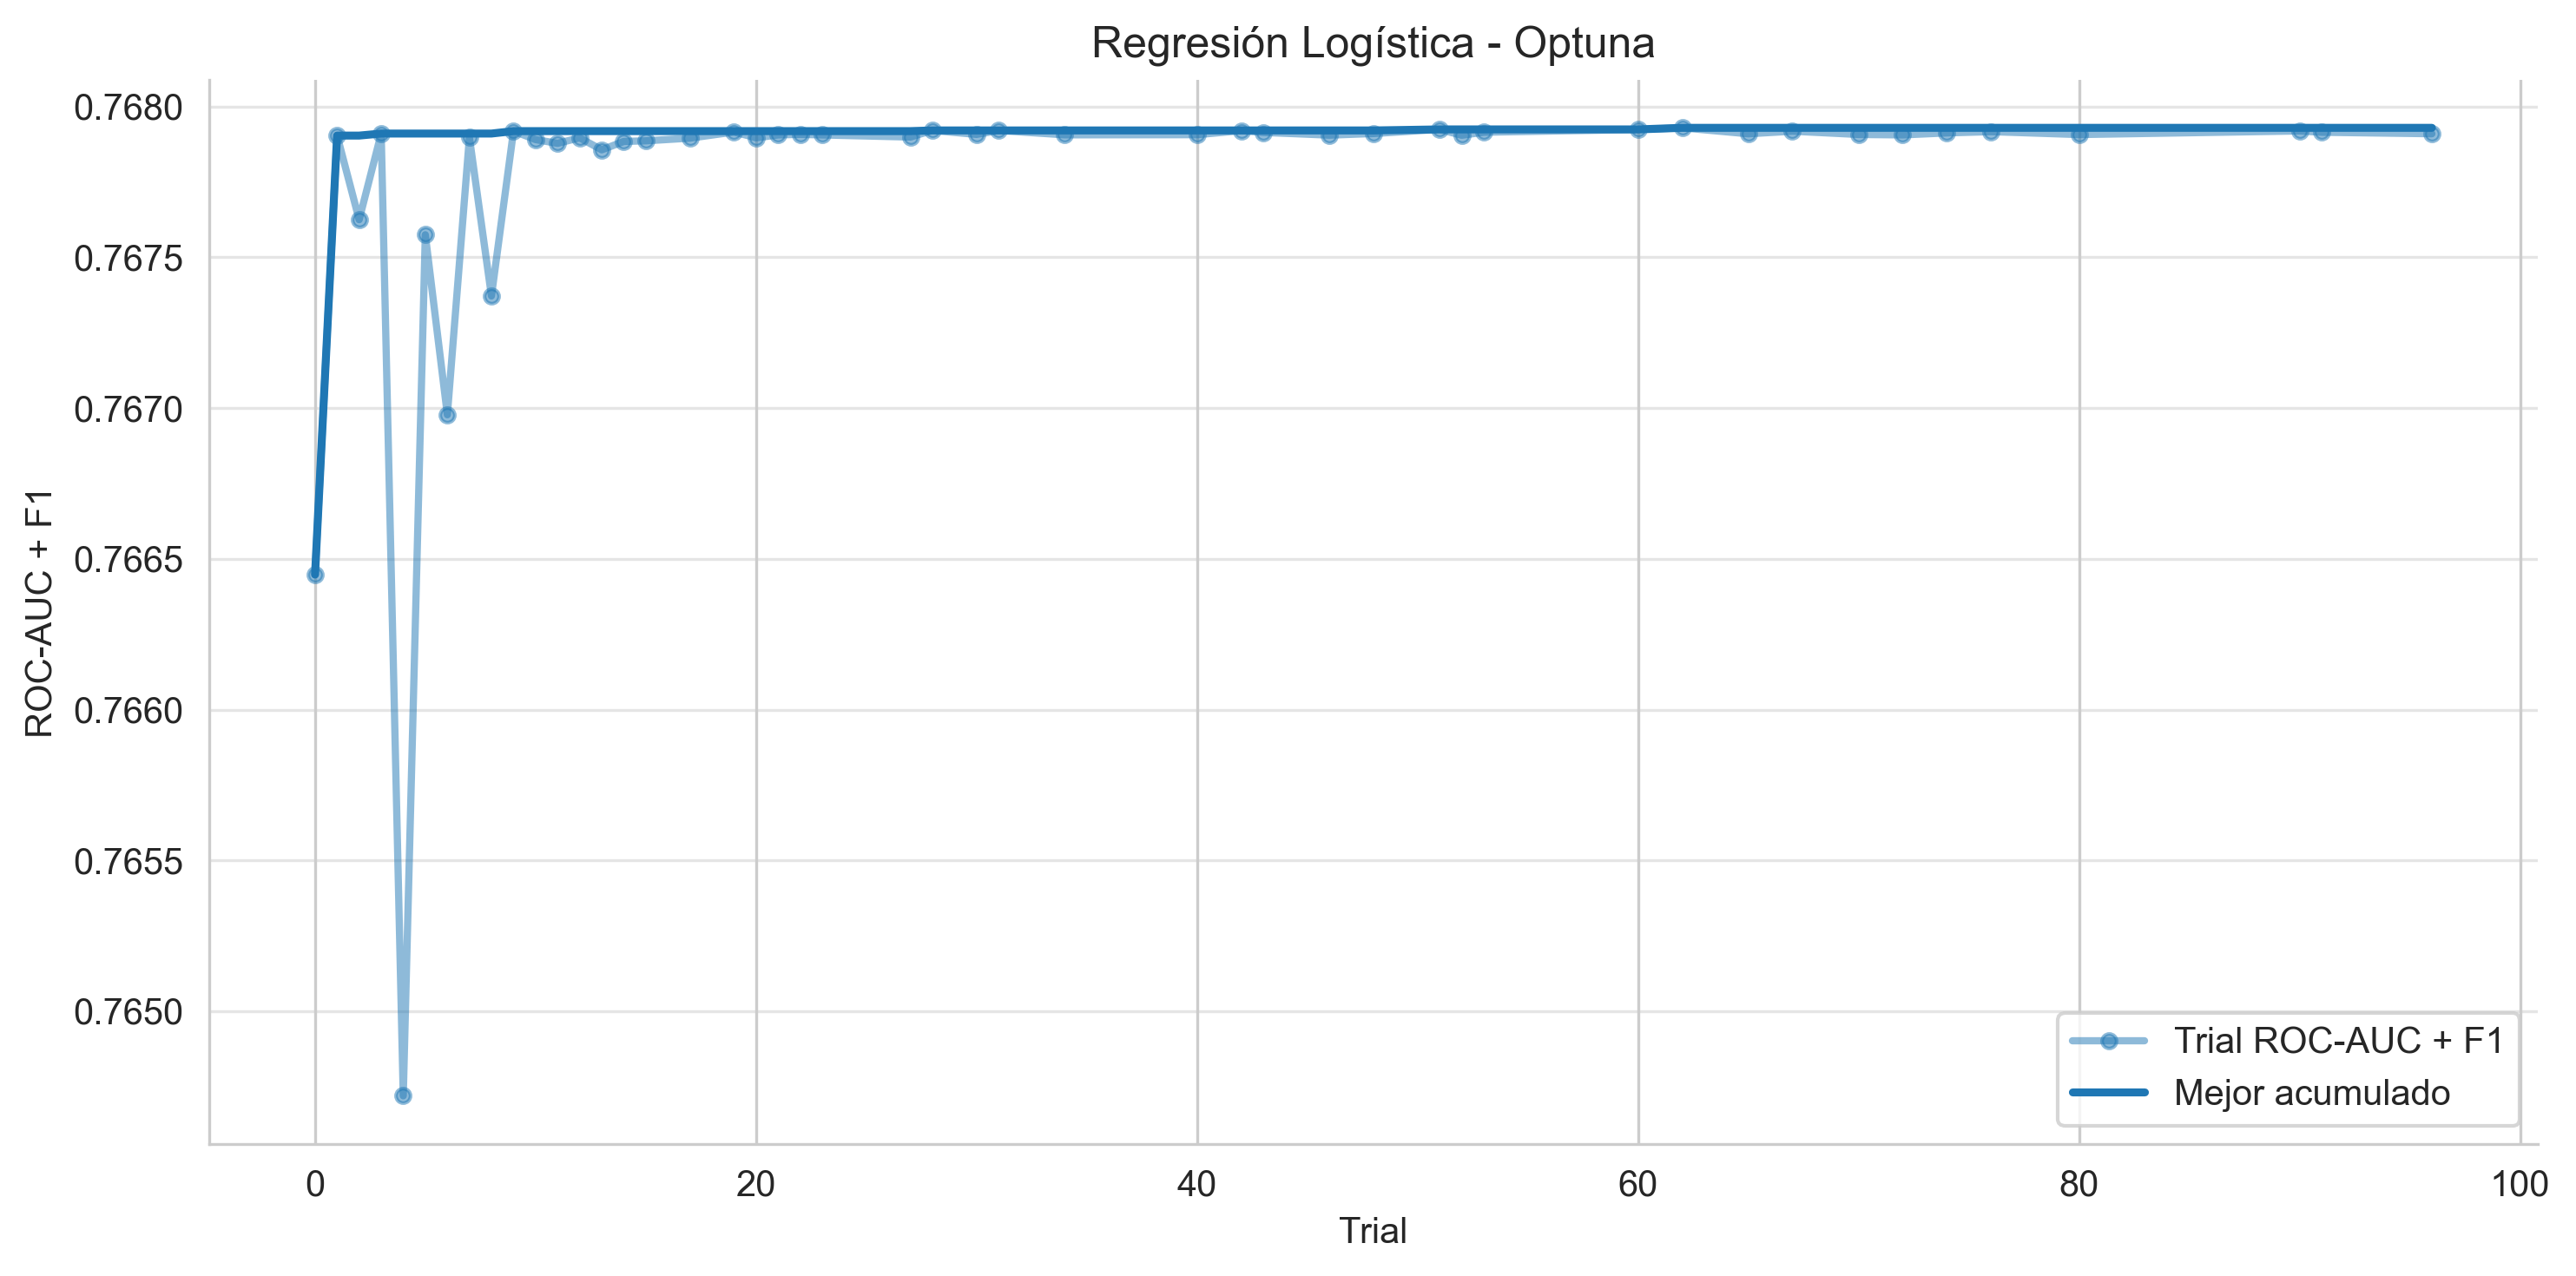

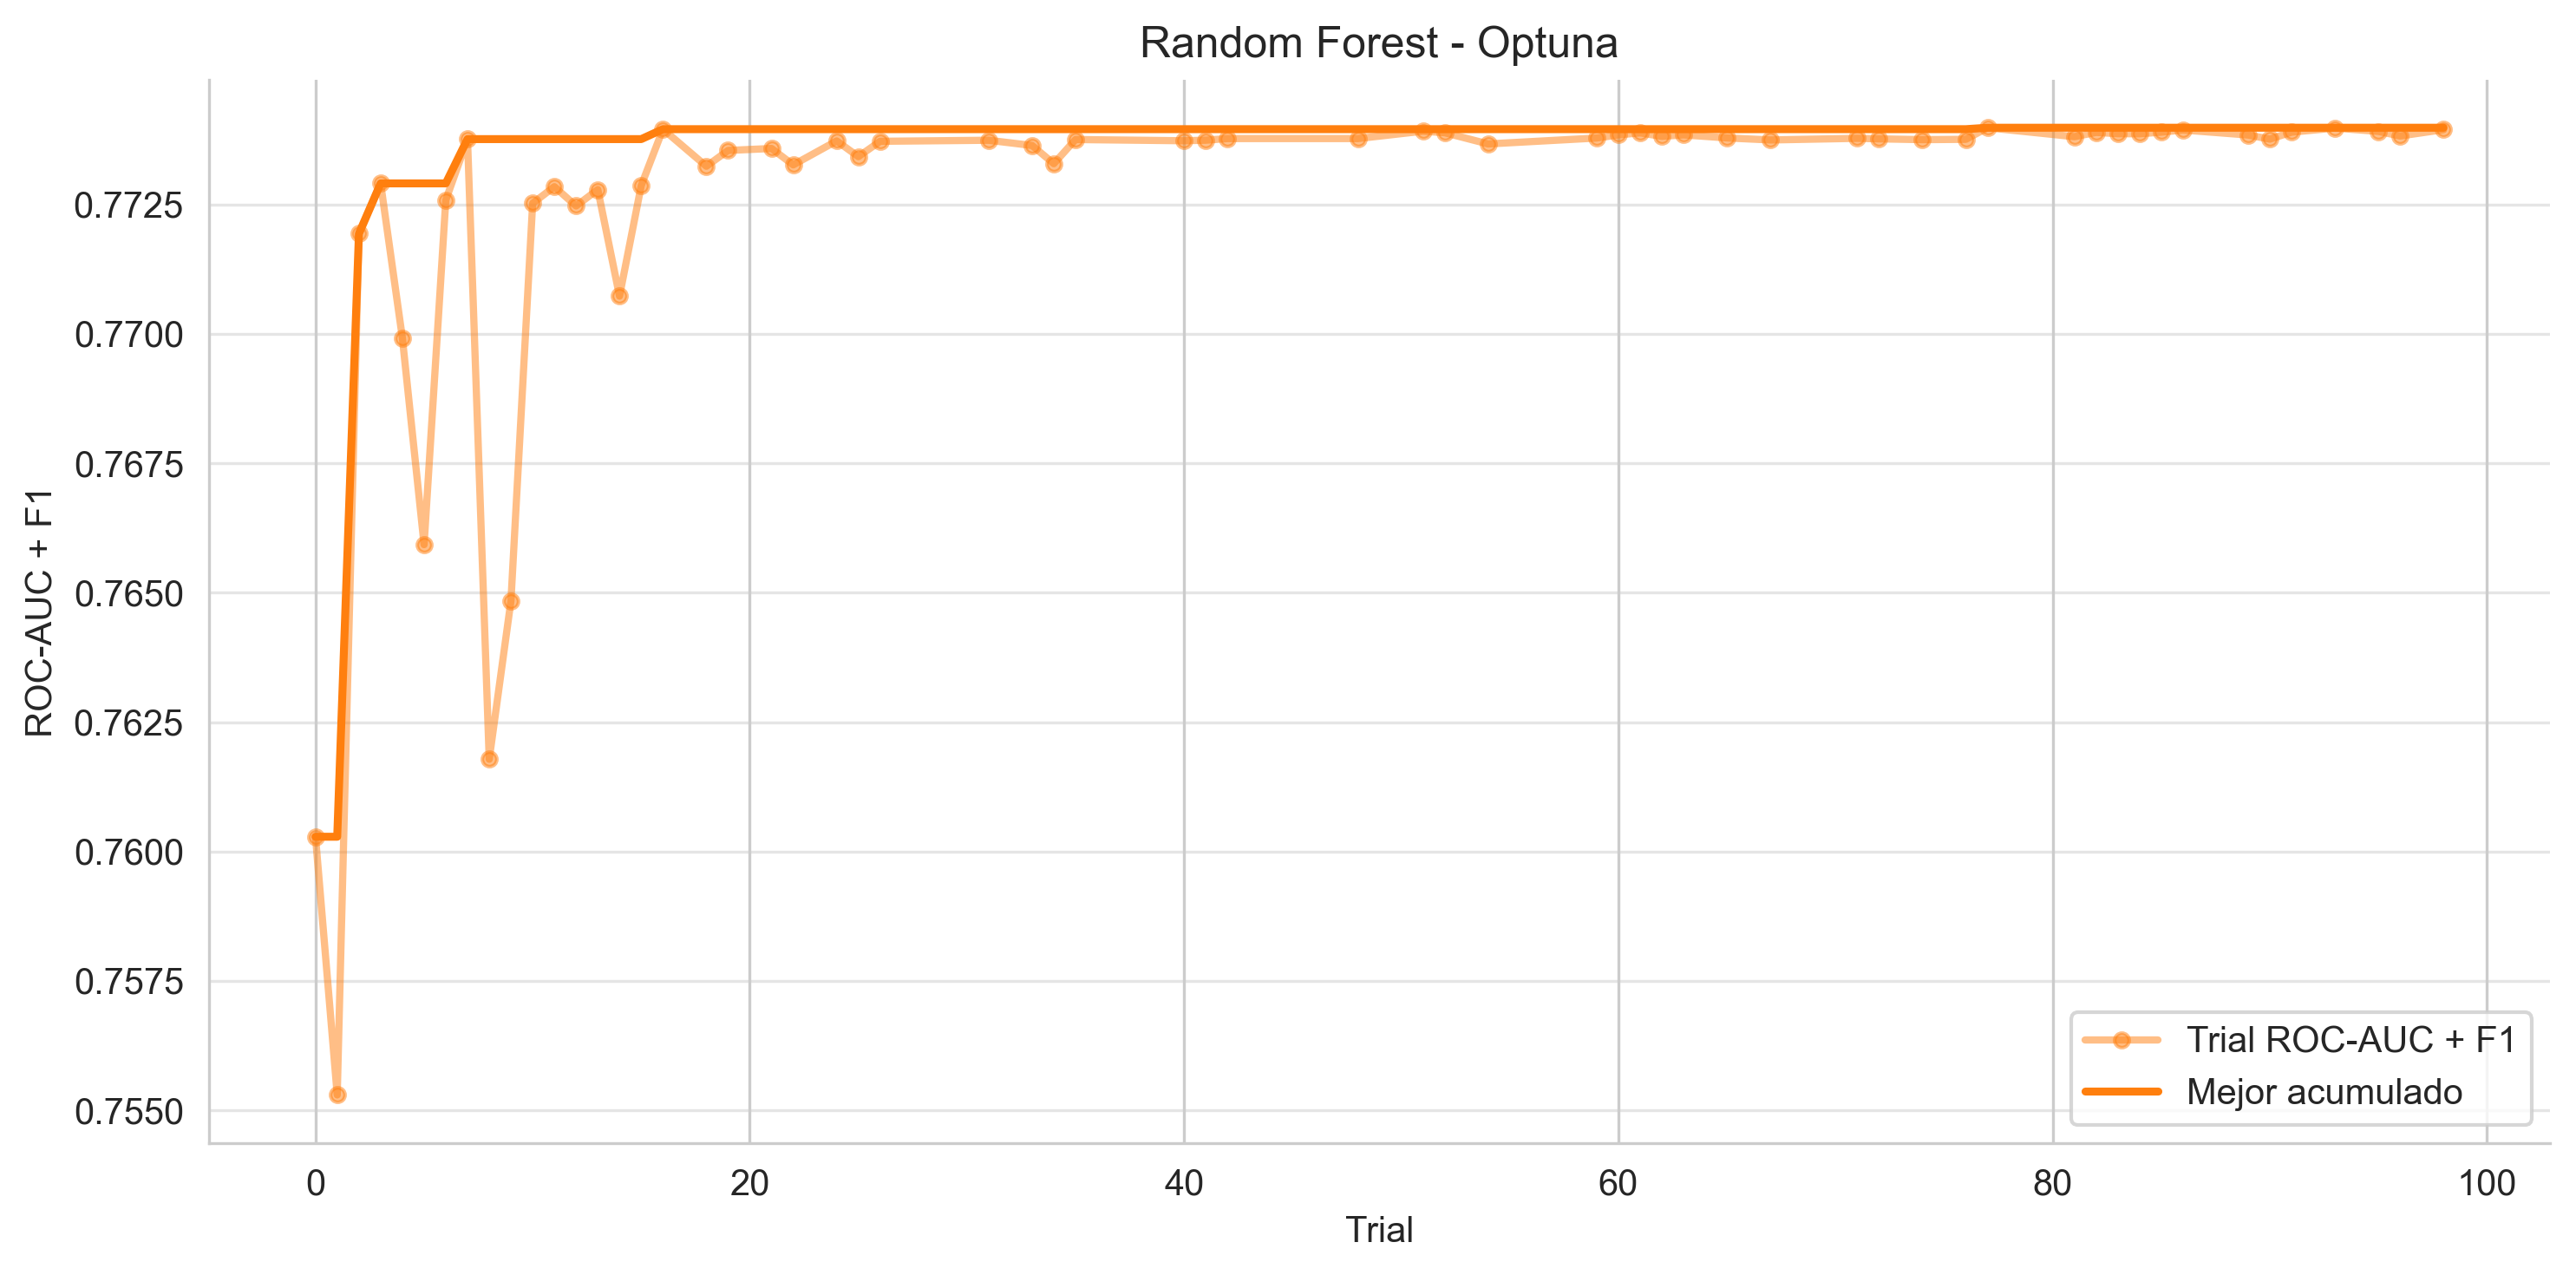

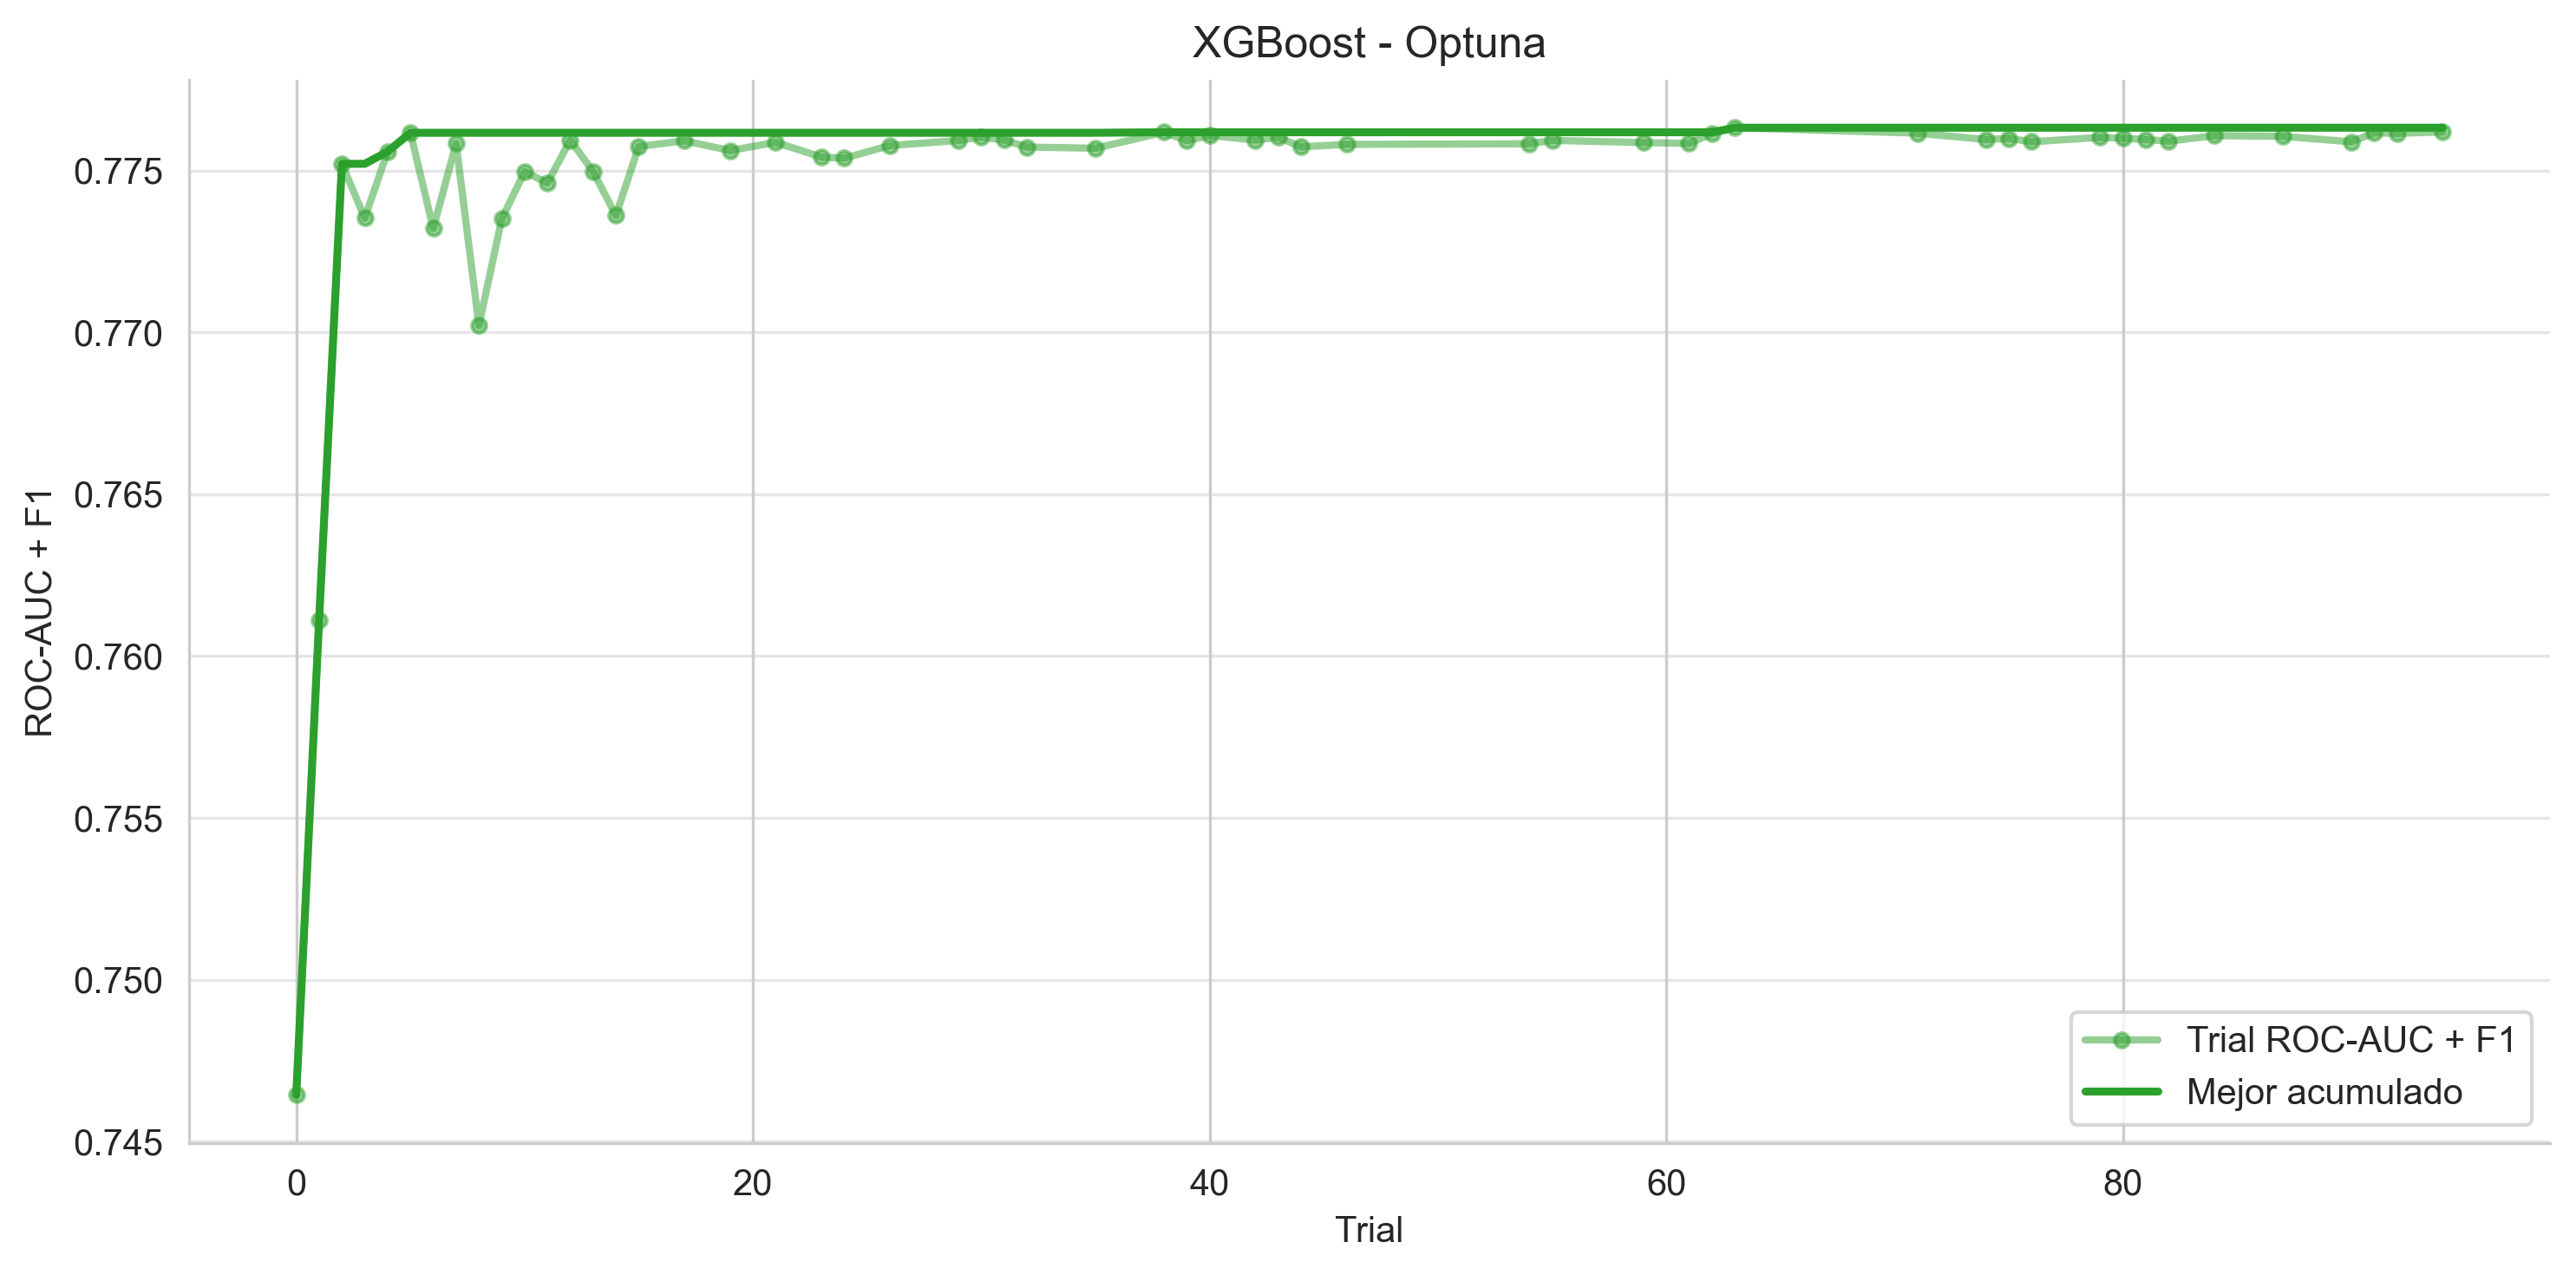

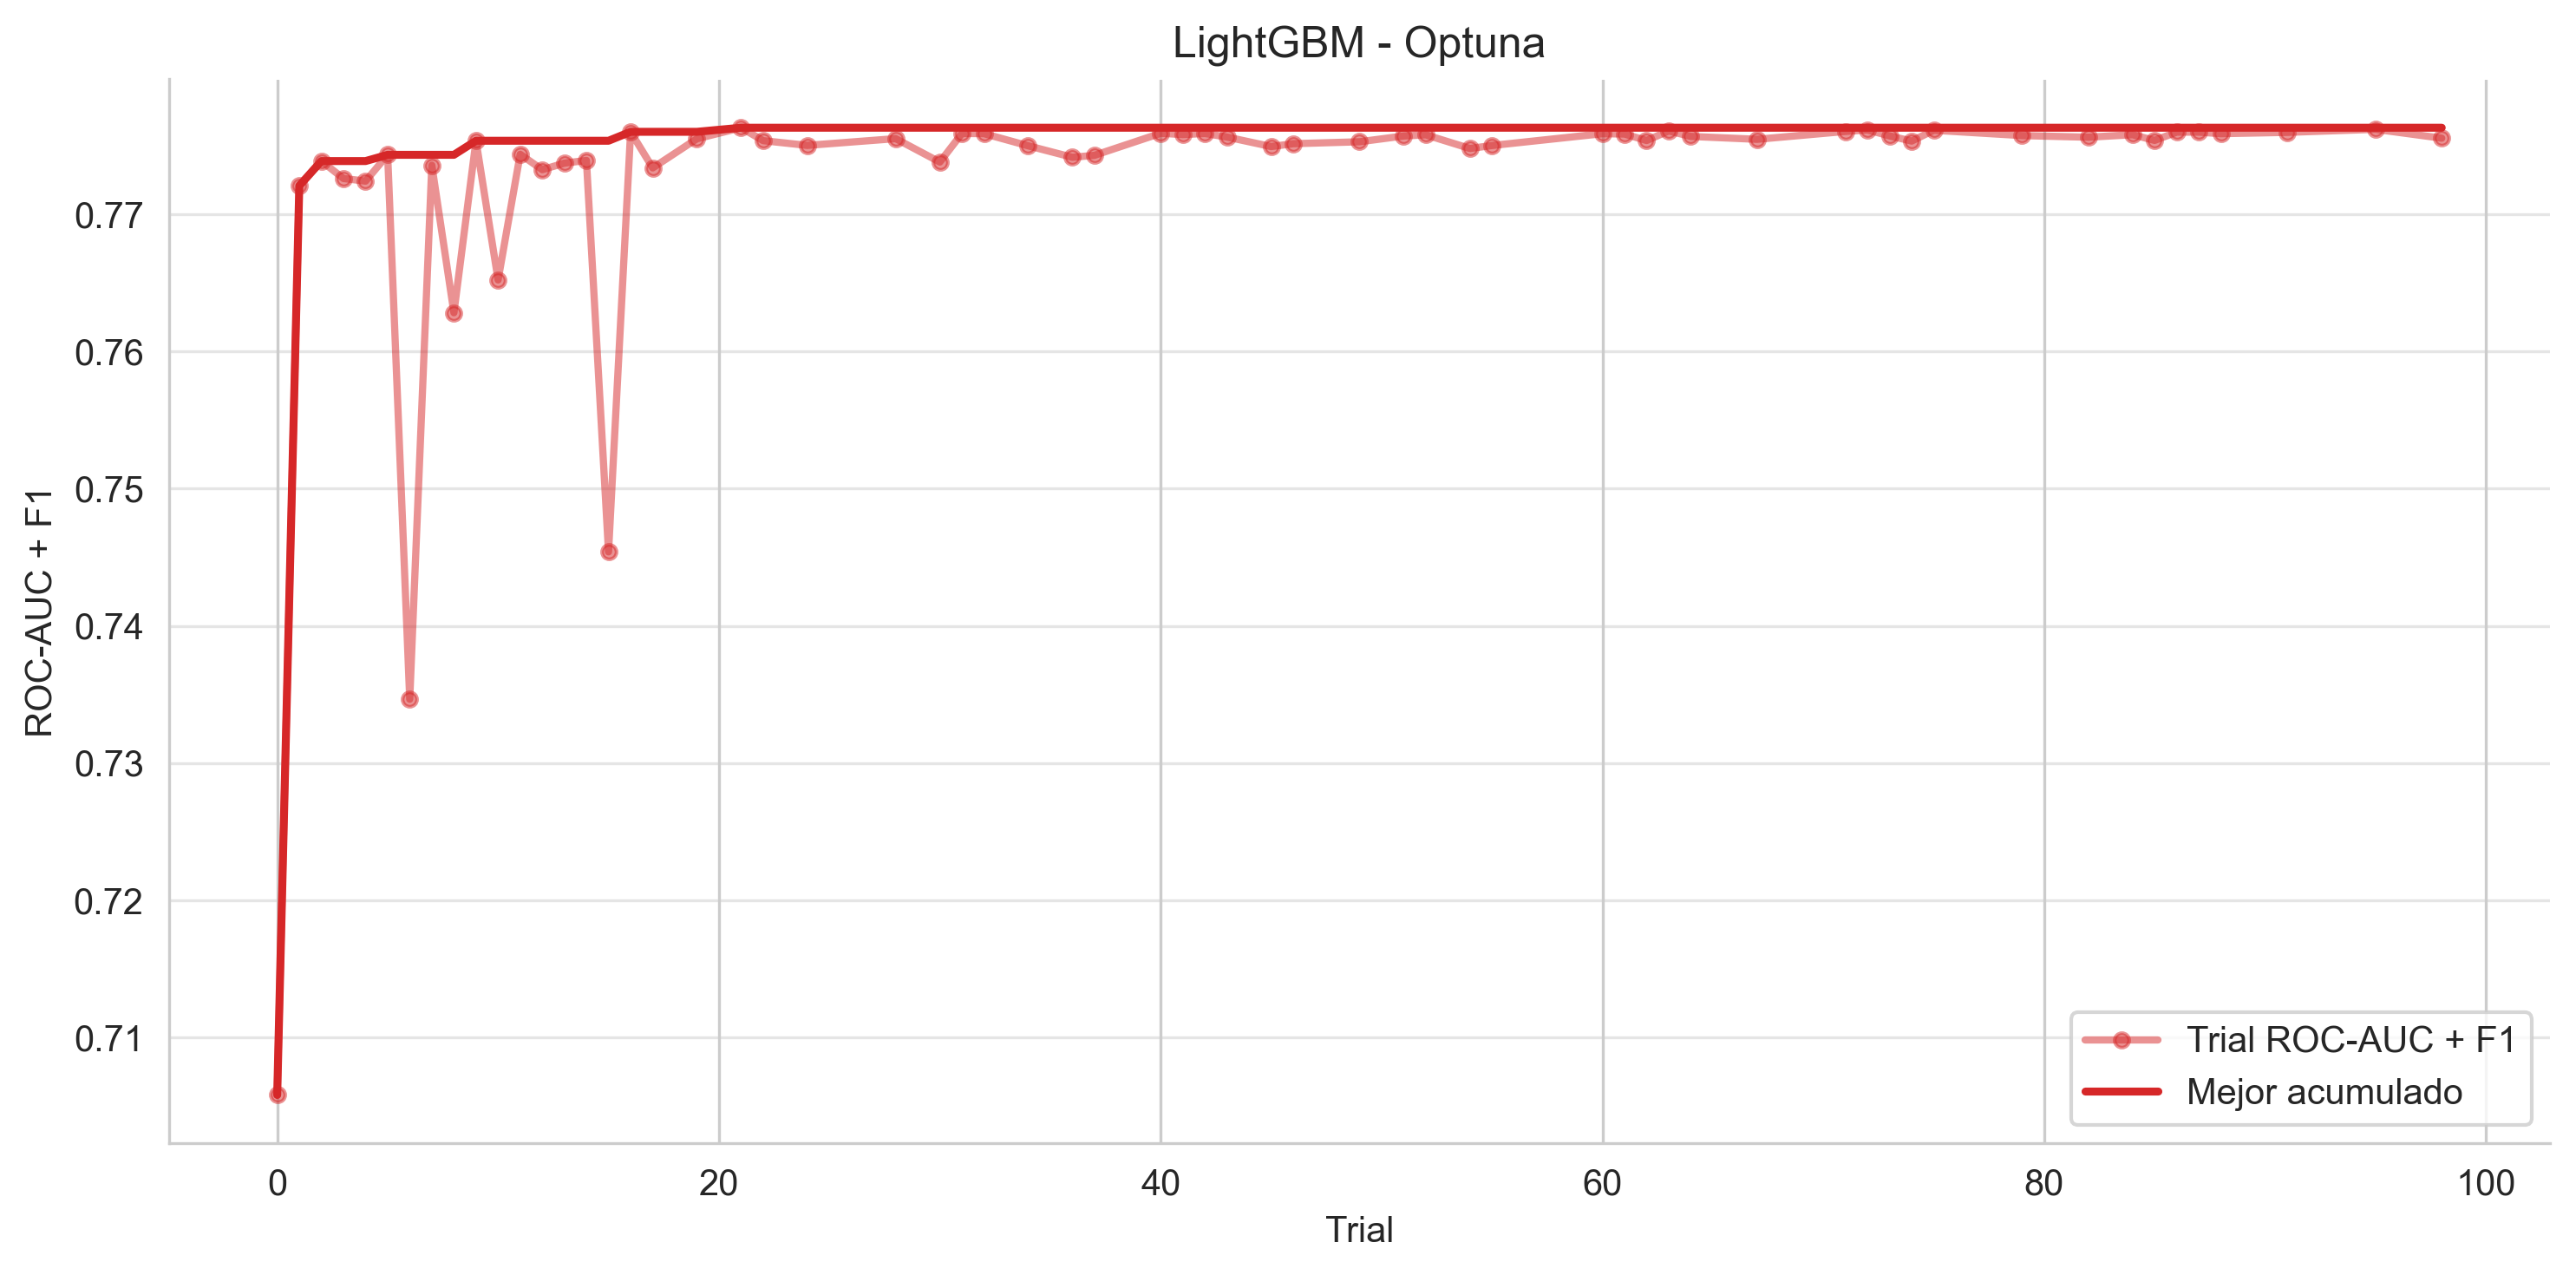

""


In [7]:
def plot_trials(trials_data, models, title_suffix=""):
    available_models = [m for m in models if m in trials_data]
    if not available_models:
        print("No hay optuna_trials_*.csv para este experimento.")
        return pd.DataFrame()

    best_trials = []

    for model in models:
        if model not in trials_data:
            continue

        tdf = trials_data[model].copy()
        if "number" not in tdf.columns:
            tdf = tdf.reset_index().rename(columns={"index": "number"})
        if "state" in tdf.columns:
            tdf = tdf[tdf["state"].astype(str).str.upper() == "COMPLETE"].copy()
        if tdf.empty or "value" not in tdf.columns:
            print(f"{MODEL_NAMES.get(model, model)} (sin trials completos)")
            continue

        tdf = tdf.sort_values("number").reset_index(drop=True)
        tdf["best_so_far"] = tdf["value"].cummax()
        model_label = MODEL_NAMES.get(model, model)
        line_color = COLORES.get(model_label, "#1f77b4")

        plt.figure(figsize=(10, 5))
        plt.plot(
            tdf["number"],
            tdf["value"],
            marker="o",
            markersize=4,
            alpha=0.5,
            linewidth=2,
            color=line_color,
            label="Trial ROC-AUC + F1",
        )
        plt.plot(
            tdf["number"],
            tdf["best_so_far"],
            linewidth=2.2,
            color=line_color,
            label="Mejor acumulado",
        )
        plt.title(f"{model_label} - Optuna{title_suffix}")
        plt.xlabel("Trial")
        plt.ylabel("ROC-AUC + F1")
        plt.grid(axis="y", alpha=0.5)
        plt.gca().set_axisbelow(True)
        plt.legend()
        sns.despine()
        plt.tight_layout()
        plt.show()

    if not best_trials:
        return pd.DataFrame()

    return pd.DataFrame(best_trials)

best_trials_df = plot_trials(trials_data, MODELS)
best_trials_df 


## 7. Análisis Global

### 7.1 Evolución de Métricas Clave (Todos los Experimentos)

In [8]:
def load_metric_evolution(metric_name, num_experiments=20):
    """Carga la evolución de una métrica a lo largo de experimentos."""
    data = []
    experiments = range(1, num_experiments + 1)

    for exp in experiments:
        exp_path = MODELS_DIR / f'Experimento{exp}' / 'training_artifacts'
        for model in MODELS:
            metrics_file = exp_path / f'val_metrics_{model}.csv'
            if metrics_file.exists():
                df_metrics = pd.read_csv(metrics_file)
                if metric_name in df_metrics.columns:
                    value = df_metrics[metric_name].values[0]
                    data.append({
                        'Experimento': exp,
                        'Modelo': MODEL_NAMES[model],
                        'Modelo_Code': model,
                        'Métrica': value,
                    })

    return pd.DataFrame(data)

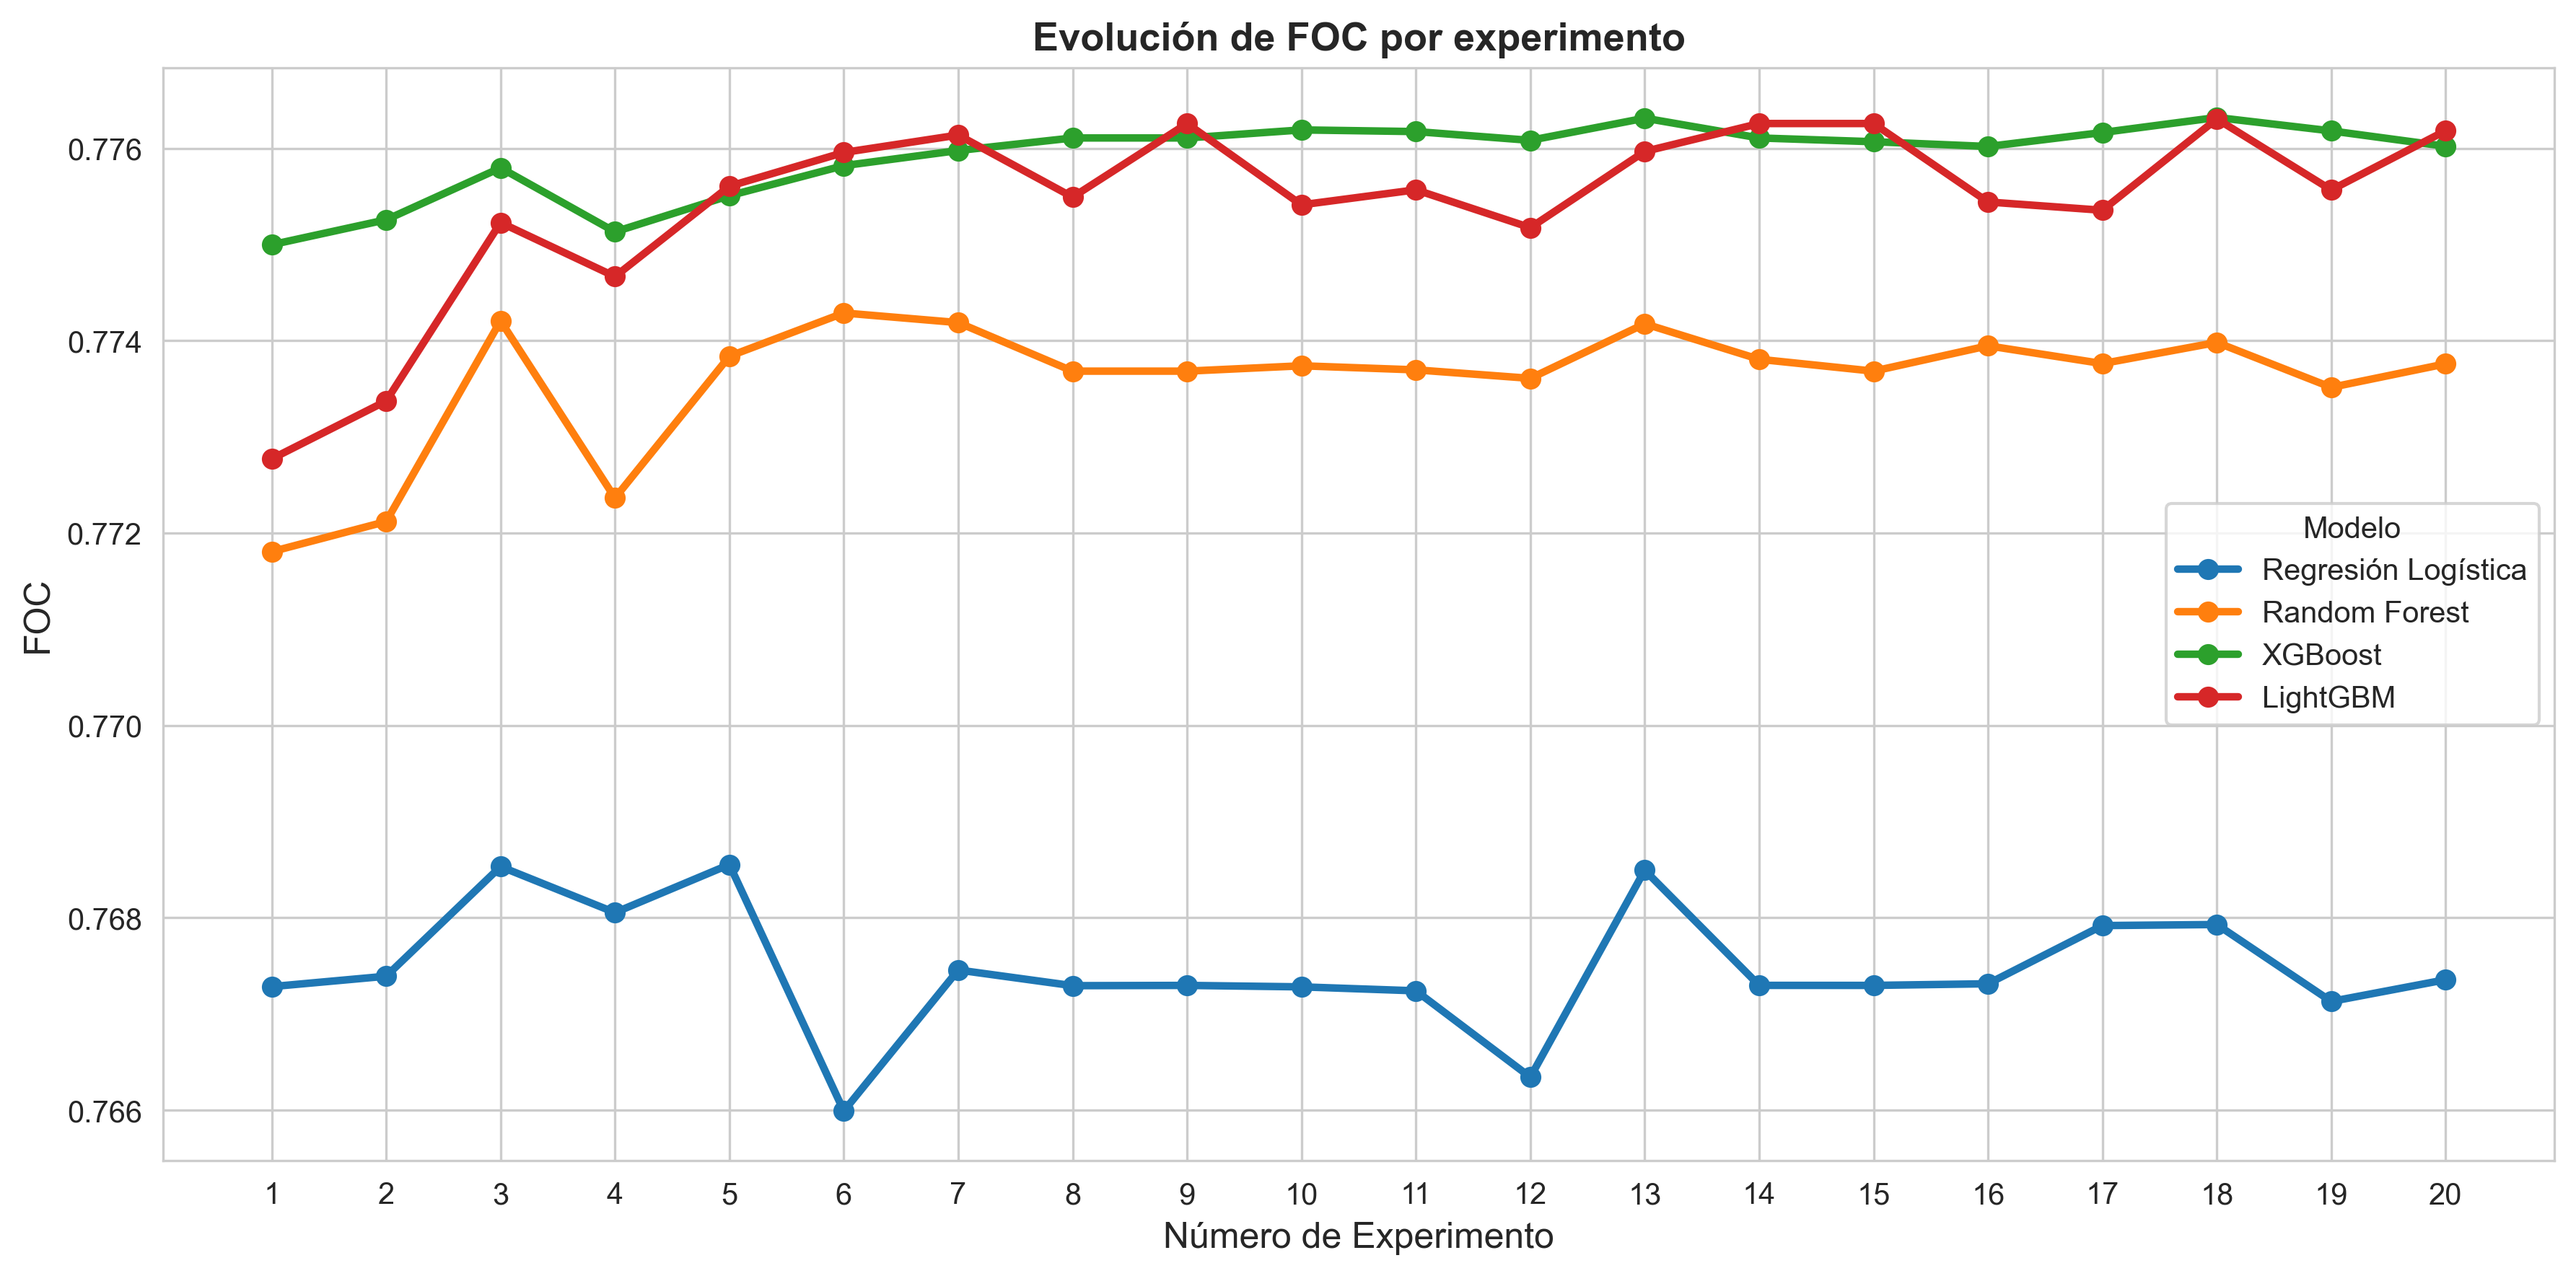


ESTADÍSTICAS DE FOC POR MODELO
                      Media  Desv. Std     Mín     Máx
Modelo                                                
LightGBM             0.7754     0.0009  0.7728  0.7763
Random Forest        0.7736     0.0007  0.7718  0.7743
Regresión Logística  0.7675     0.0006  0.7660  0.7686
XGBoost              0.7759     0.0004  0.7750  0.7763

MEJOR EXPERIMENTO POR MODELO (FOC)
                Modelo  Experimento   Métrica
0              XGBoost           18  0.776321
1             LightGBM           18  0.776306
2        Random Forest            6  0.774288
3  Regresión Logística            5  0.768553


In [11]:
# Cargar FOC
df_f2 = load_metric_evolution('best_cv_composite_score')

plt.figure(figsize=(12, 6))
for model_code in MODELS:
    model_name = MODEL_NAMES[model_code]
    data1 = df_f2[df_f2['Modelo_Code'] == model_code]
    plt.plot(data1['Experimento'], data1['Métrica'], marker='o', label=model_name, linewidth=2.5)

plt.xlabel('Número de Experimento', fontsize=12)
plt.ylabel('FOC', fontsize=12)
plt.title('Evolución de FOC por experimento', fontsize=13, fontweight='bold')
plt.legend(title = 'Modelo', loc='best')
plt.grid(True)
plt.xticks(range(1, 21))
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'report/figures/training/composite_score_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n' + '='*70)
print('ESTADÍSTICAS DE FOC POR MODELO')
print('='*70)
stats = df_f2.groupby('Modelo')['Métrica'].agg([
    ('Media', 'mean'),
    ('Desv. Std', 'std'),
    ('Mín', 'min'),
    ('Máx', 'max'),
]).round(4)
print(stats)

# Mejor experimento por modelo
print('\n' + '='*70)
print('MEJOR EXPERIMENTO POR MODELO (FOC)')
print('='*70)
best_experiments_f2 = df_f2.loc[df_f2.groupby('Modelo')['Métrica'].idxmax()]
print(best_experiments_f2[['Modelo', 'Experimento', 'Métrica']].sort_values('Métrica', ascending=False).reset_index(drop=True))



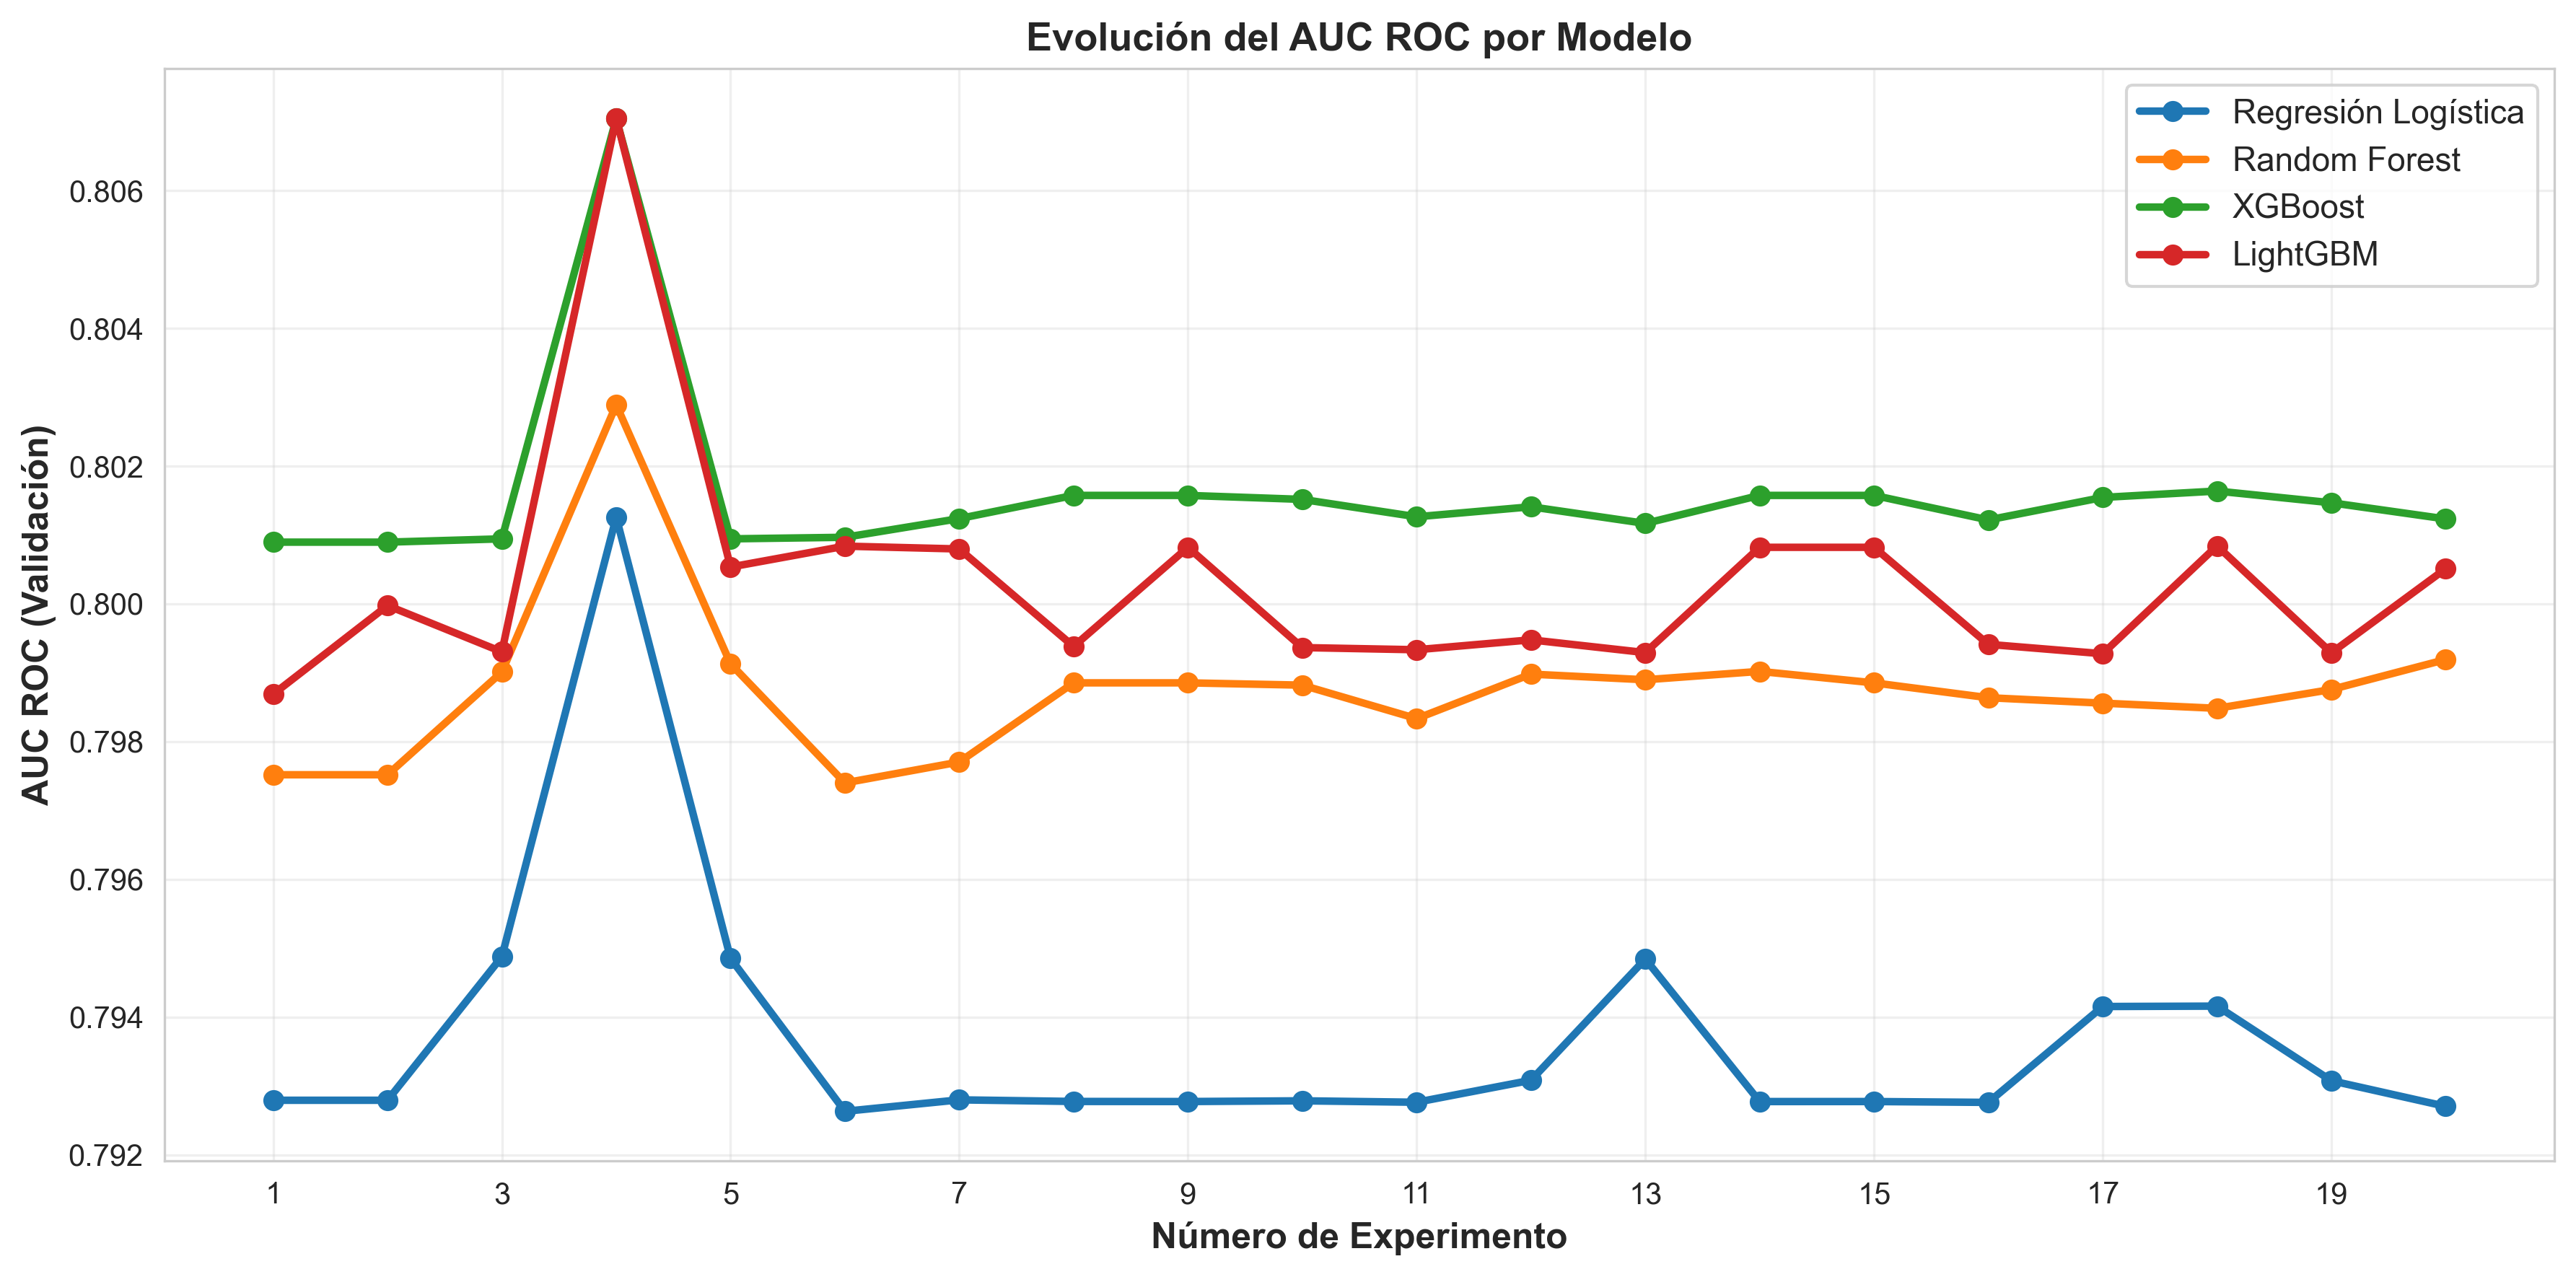


ESTADÍSTICAS DE AUC ROC POR MODELO
                      Media  Desv. Std     Mín     Máx
Modelo                                                
LightGBM             0.8003     0.0018  0.7987  0.8070
Random Forest        0.7988     0.0011  0.7974  0.8029
Regresión Logística  0.7937     0.0020  0.7926  0.8013
XGBoost              0.8016     0.0013  0.8009  0.8070

MEJOR EXPERIMENTO POR MODELO (AUC ROC Validación)
                Modelo  Experimento   Métrica
0             LightGBM            4  0.807050
1              XGBoost            4  0.807044
2        Random Forest            4  0.802889
3  Regresión Logística            4  0.801258


In [12]:
# Cargar AUC ROC
df_auc = load_metric_evolution('val_roc_auc')

plt.figure(figsize=(12, 6))
for model_code in MODELS:
    model_name = MODEL_NAMES[model_code]
    data = df_auc[df_auc['Modelo_Code'] == model_code]
    plt.plot(data['Experimento'], data['Métrica'], marker='o', label=model_name, linewidth=2.5)

plt.xlabel('Número de Experimento', fontsize=12, fontweight='bold')
plt.ylabel('AUC ROC (Validación)', fontsize=12, fontweight='bold')
plt.title('Evolución del AUC ROC por Modelo', fontsize=13, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 21, 2))
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'report/figures/training/auc_roc_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

# Estadísticas por modelo
print('\n' + '='*70)
print('ESTADÍSTICAS DE AUC ROC POR MODELO')
print('='*70)
stats = df_auc.groupby('Modelo')['Métrica'].agg([
    ('Media', 'mean'),
    ('Desv. Std', 'std'),
    ('Mín', 'min'),
    ('Máx', 'max'),
]).round(4)
print(stats)

# Mejor experimento por modelo
print('\n' + '='*70)
print('MEJOR EXPERIMENTO POR MODELO (AUC ROC Validación)')
print('='*70)
best_experiments = df_auc.loc[df_auc.groupby('Modelo')['Métrica'].idxmax()]
print(best_experiments[['Modelo', 'Experimento', 'Métrica']].sort_values('Métrica', ascending=False).reset_index(drop=True))


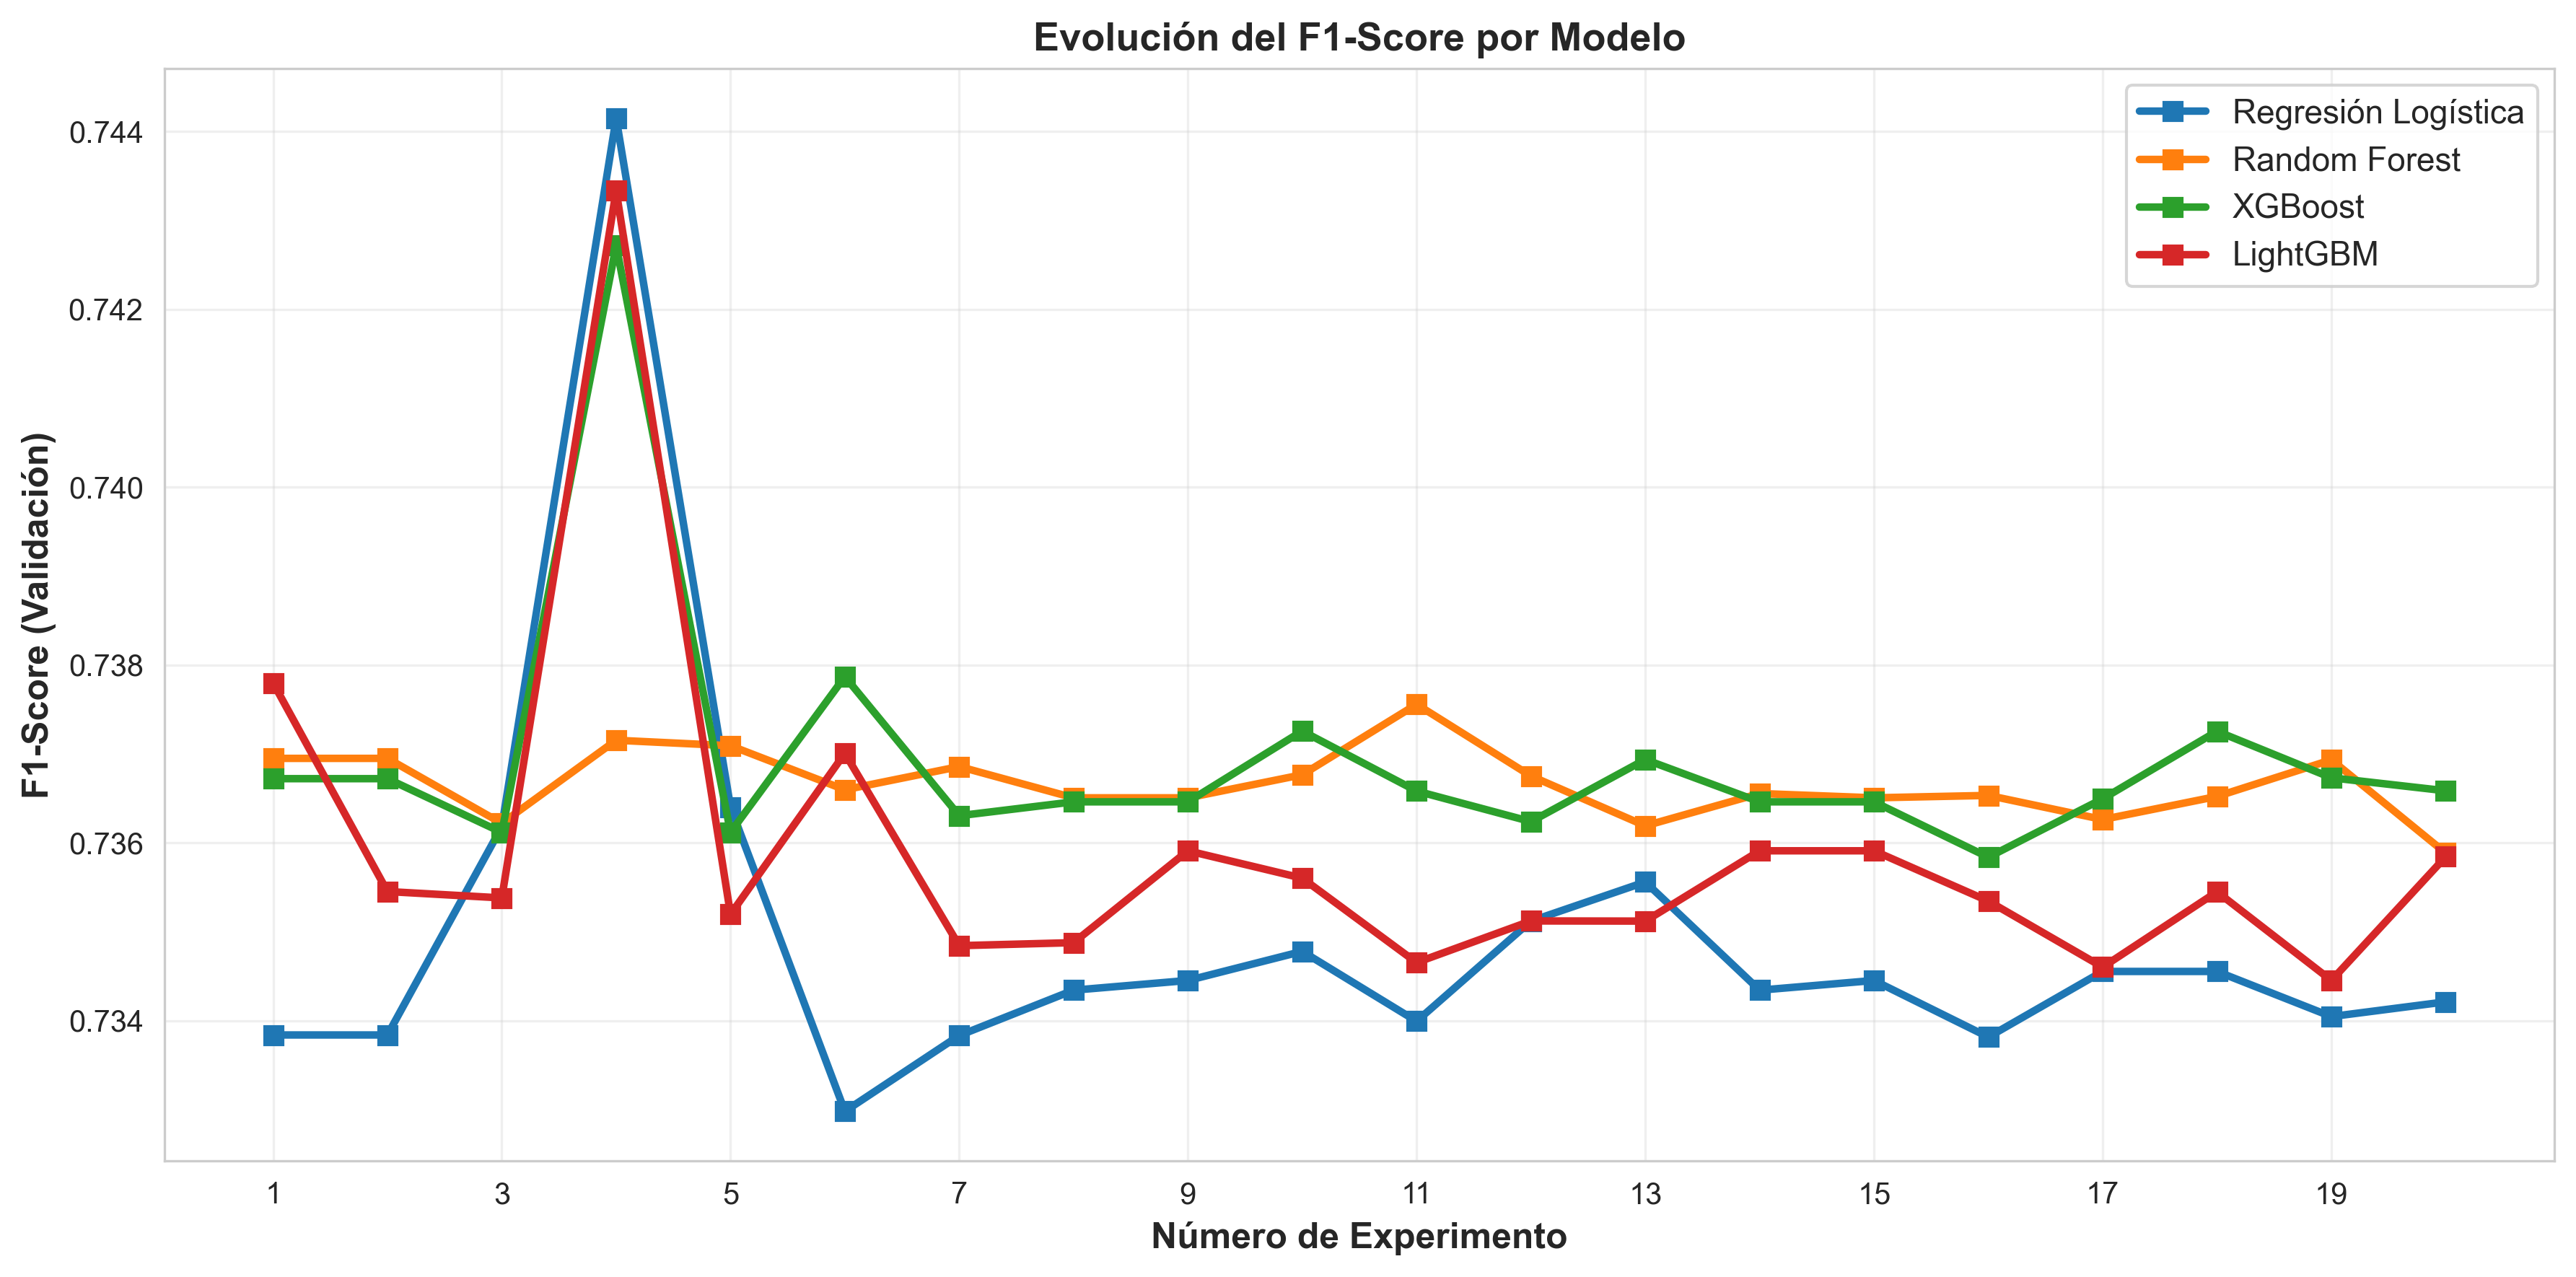


ESTADÍSTICAS DE F1-SCORE POR MODELO
                      Media  Desv. Std     Mín     Máx
Modelo                                                
LightGBM             0.7359     0.0019  0.7345  0.7433
Random Forest        0.7367     0.0004  0.7359  0.7376
Regresión Logística  0.7350     0.0023  0.7330  0.7442
XGBoost              0.7369     0.0014  0.7358  0.7427

MEJOR EXPERIMENTO POR MODELO (F1-Score Validación)
                Modelo  Experimento   Métrica
0  Regresión Logística            4  0.744151
1             LightGBM            4  0.743336
2              XGBoost            4  0.742718
3        Random Forest           11  0.737558


In [13]:
# Cargar F1-Score
df_f1 = load_metric_evolution('val_f1_score')

plt.figure(figsize=(12, 6))
for model_code in MODELS:
    model_name = MODEL_NAMES[model_code]
    data = df_f1[df_f1['Modelo_Code'] == model_code]
    plt.plot(data['Experimento'], data['Métrica'], marker='s', label=model_name, linewidth=2.5)

plt.xlabel('Número de Experimento', fontsize=12, fontweight='bold')
plt.ylabel('F1-Score (Validación)', fontsize=12, fontweight='bold')
plt.title('Evolución del F1-Score por Modelo', fontsize=13, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 21, 2))
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'report/figures/training/f1_score_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n' + '='*70)
print('ESTADÍSTICAS DE F1-SCORE POR MODELO')
print('='*70)
stats = df_f1.groupby('Modelo')['Métrica'].agg([
    ('Media', 'mean'),
    ('Desv. Std', 'std'),
    ('Mín', 'min'),
    ('Máx', 'max'),
]).round(4)
print(stats)

# Mejor experimento por modelo
print('\n' + '='*70)
print('MEJOR EXPERIMENTO POR MODELO (F1-Score Validación)')
print('='*70)
best_experiments_f1 = df_f1.loc[df_f1.groupby('Modelo')['Métrica'].idxmax()]
print(best_experiments_f1[['Modelo', 'Experimento', 'Métrica']].sort_values('Métrica', ascending=False).reset_index(drop=True))

## 8. Analisis Individual por Experimento

### 8.1 Métricas de Validación

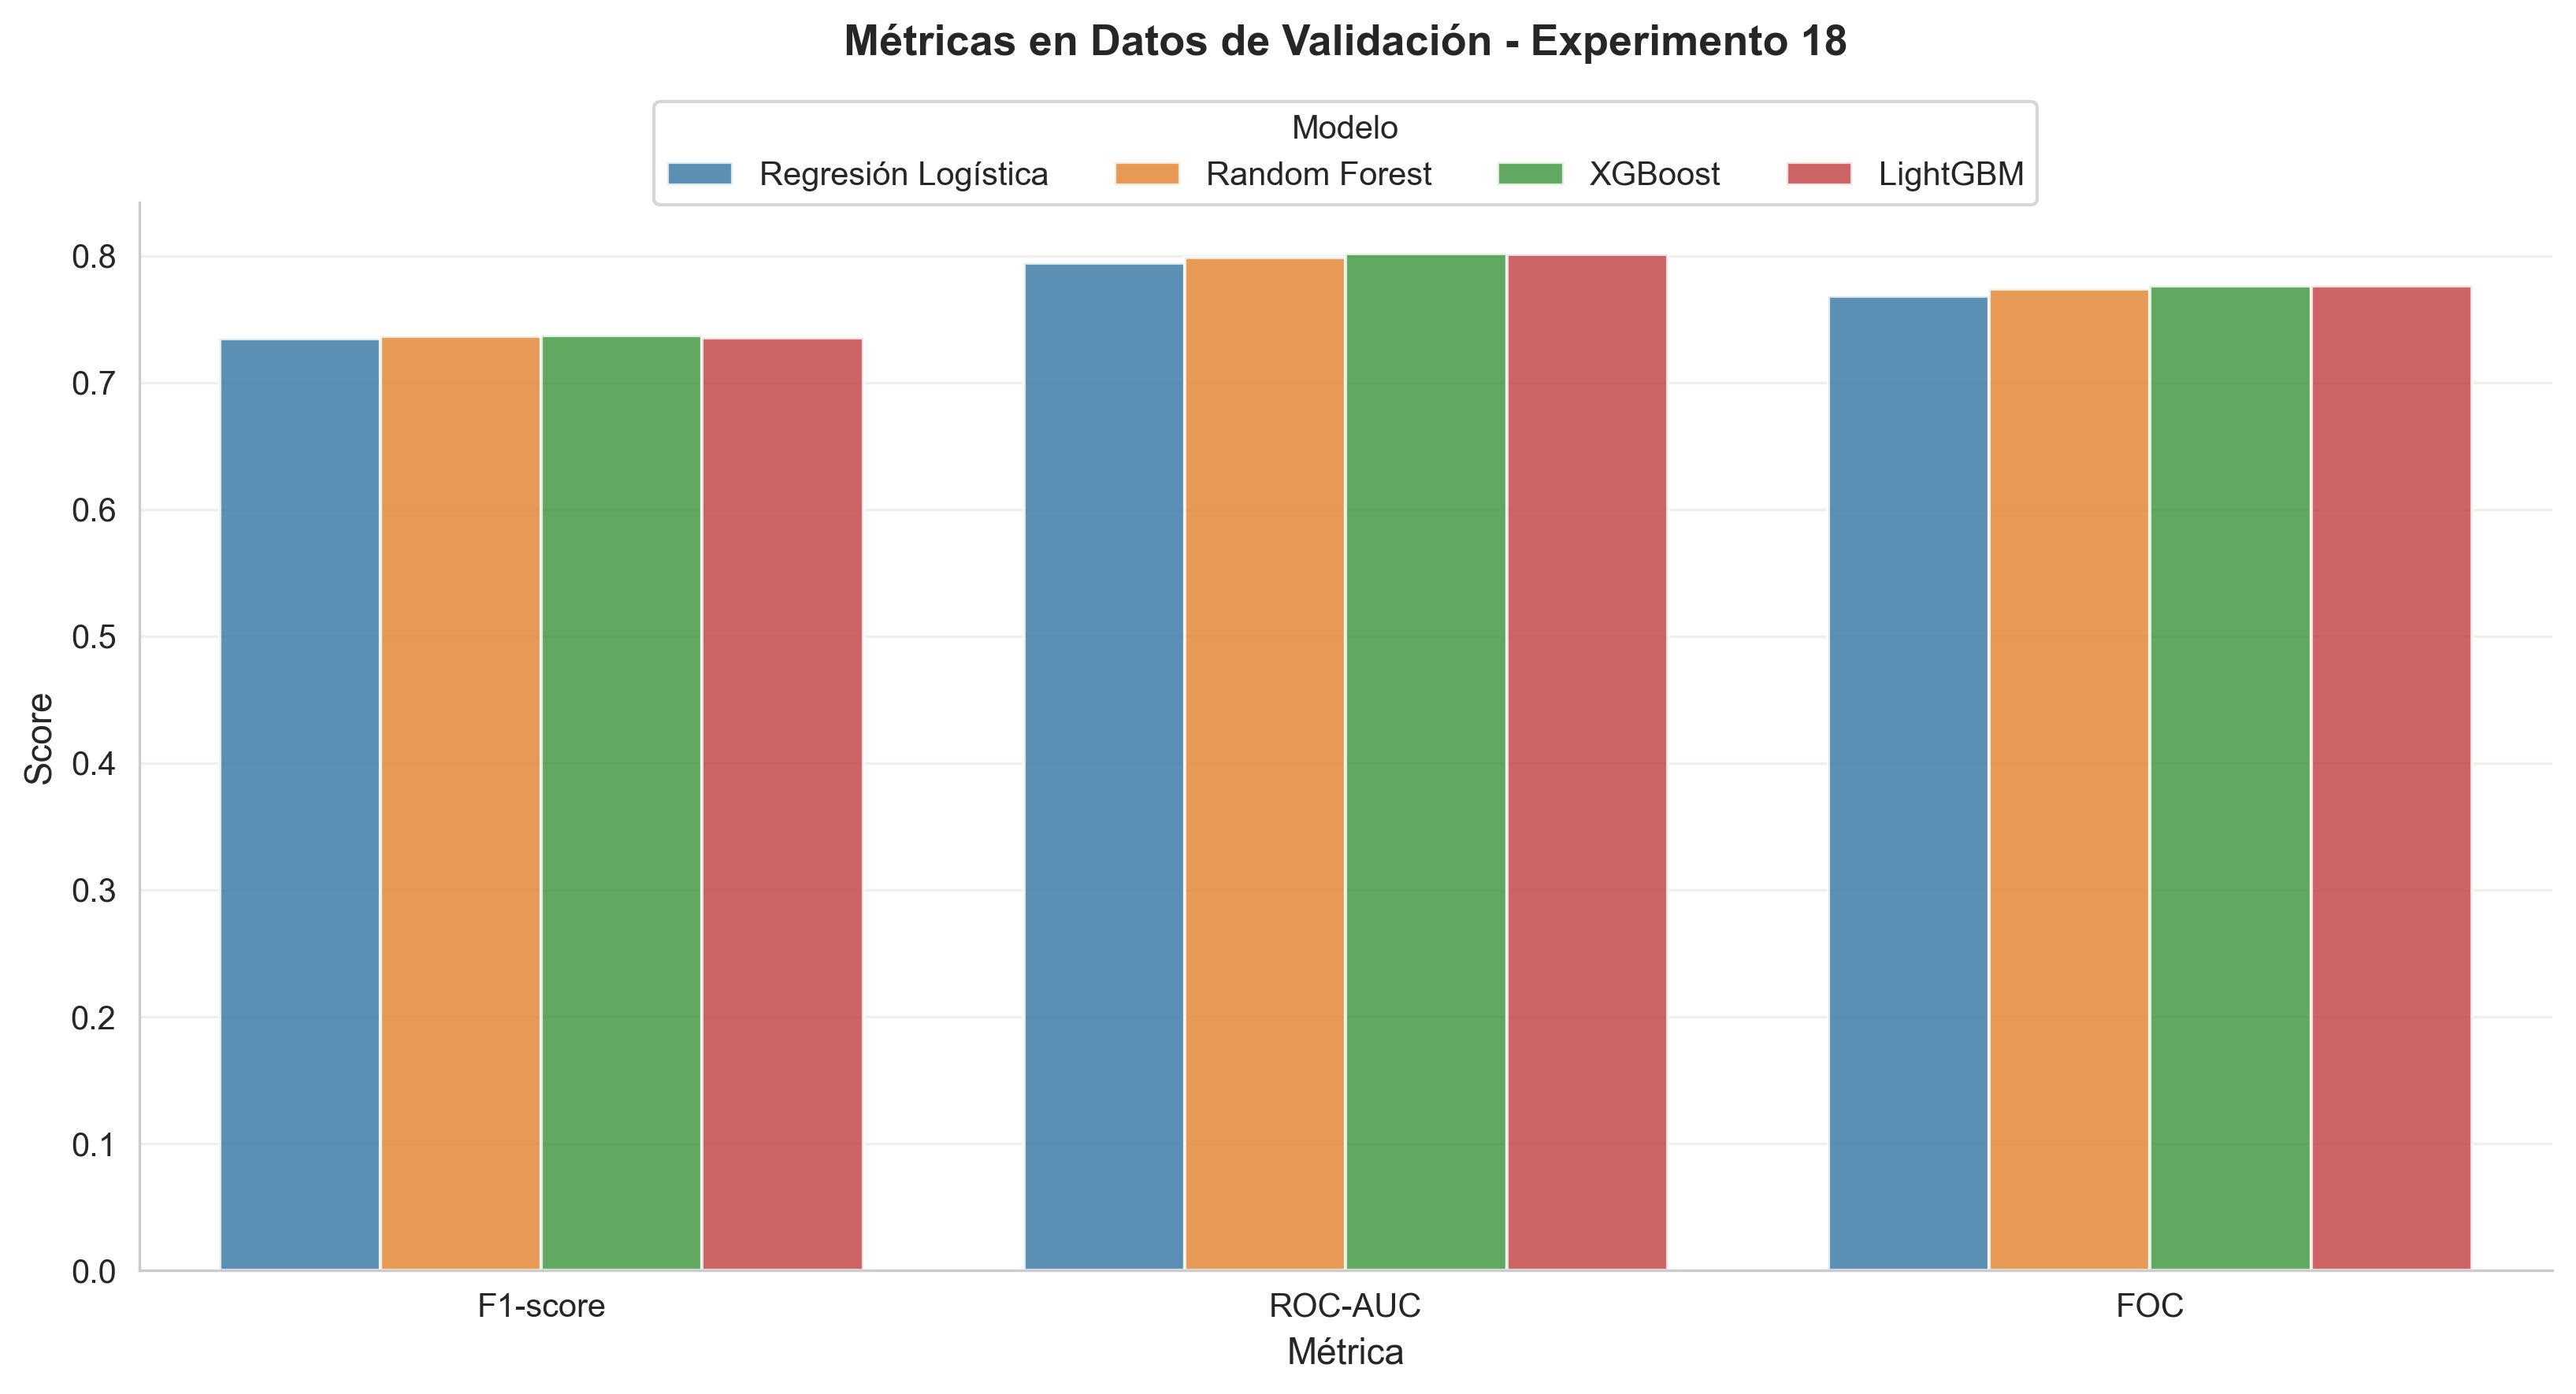

,model_name,F1-score,ROC-AUC,FOC
0,XGBoost,0.737255,0.801638,0.776321
1,LightGBM,0.735449,0.800842,0.776306
2,Random Forest,0.736522,0.798484,0.773982
3,Regresión Logística,0.734553,0.794161,0.767930


In [15]:
from IPython.display import display as _ipy_display

def plot_validation_metrics(metrics_df):
    """Visualiza métricas de validación."""
    if metrics_df.empty:
        print('No hay métricas disponibles.')
        return

    plot_columns = ['val_f1_score', 'val_roc_auc', 'best_cv_composite_score']
    metric_labels = {
        'val_f1_score': 'F1-score',
        'val_roc_auc': 'ROC-AUC',
        'best_cv_composite_score': 'FOC',
    }

    available_columns = [c for c in plot_columns if c in metrics_df.columns]
    if not available_columns:
        print('No hay columnas de métricas esperadas.')
        return

    long_df = metrics_df.melt(
        id_vars=['model_name'],
        value_vars=available_columns,
        var_name='metric',
        value_name='score',
    )
    long_df['metric_label'] = long_df['metric'].map(metric_labels)

    hue_order = [m for m in MODEL_ORDER if m in metrics_df['model_name'].values]

    experiment_id = globals().get('SELECTED_EXPERIMENT', 'N/A')

    plt.figure(figsize=(11, 6))
    ax = sns.barplot(
        data=long_df,
        x='metric_label',
        y='score',
        hue='model_name',
        hue_order=hue_order,
        palette=COLORES,
        alpha=0.8,
    )
    ax.set_title(f'Métricas en Datos de Validación - Experimento {experiment_id}', fontsize=13, fontweight='bold', pad=45)
    ax.set_xlabel('Métrica', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)
    sns.despine()
    ax.legend(title='Modelo', loc='upper center', bbox_to_anchor=(0.5, 1.11), ncol=4, fontsize=10)
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / f'report/figures/training/validation_metrics_{experiment_id}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Tabla de resumen
    table_cols = ['model_name'] + available_columns
    display(
        metrics_df[table_cols]
        .rename(columns=metric_labels)
        .sort_values(metric_labels.get('best_cv_composite_score', available_columns[0]), ascending=False)
        .reset_index(drop=True))
if globals().get('EXPERIMENT_DIR') is not None and 'metrics_df' in globals():
    try:
        globals()['display'] = _ipy_display
    except Exception:
        import IPython.display as _ipyd
        globals()['display'] = _ipyd.display

    plot_validation_metrics(metrics_df)
else:
    print('No hay experimento seleccionado o métricas de validación cargadas.')


### 8.1 Diagnóstico de Sobreajuste

,Modelo,F1 Train,F1 Val,Gap F1,AUC Train,AUC Val,Gap AUC,Riesgo
0,Regresión Logística,0.733792,0.734553,-0.000761,0.791560,0.794161,-0.002601,bajo
1,Random Forest,0.737506,0.736522,0.000984,0.804563,0.798484,0.006079,bajo
2,XGBoost,0.743158,0.737255,0.005903,0.808437,0.801638,0.006799,bajo
3,LightGBM,0.739966,0.735449,0.004517,0.807035,0.800842,0.006193,bajo


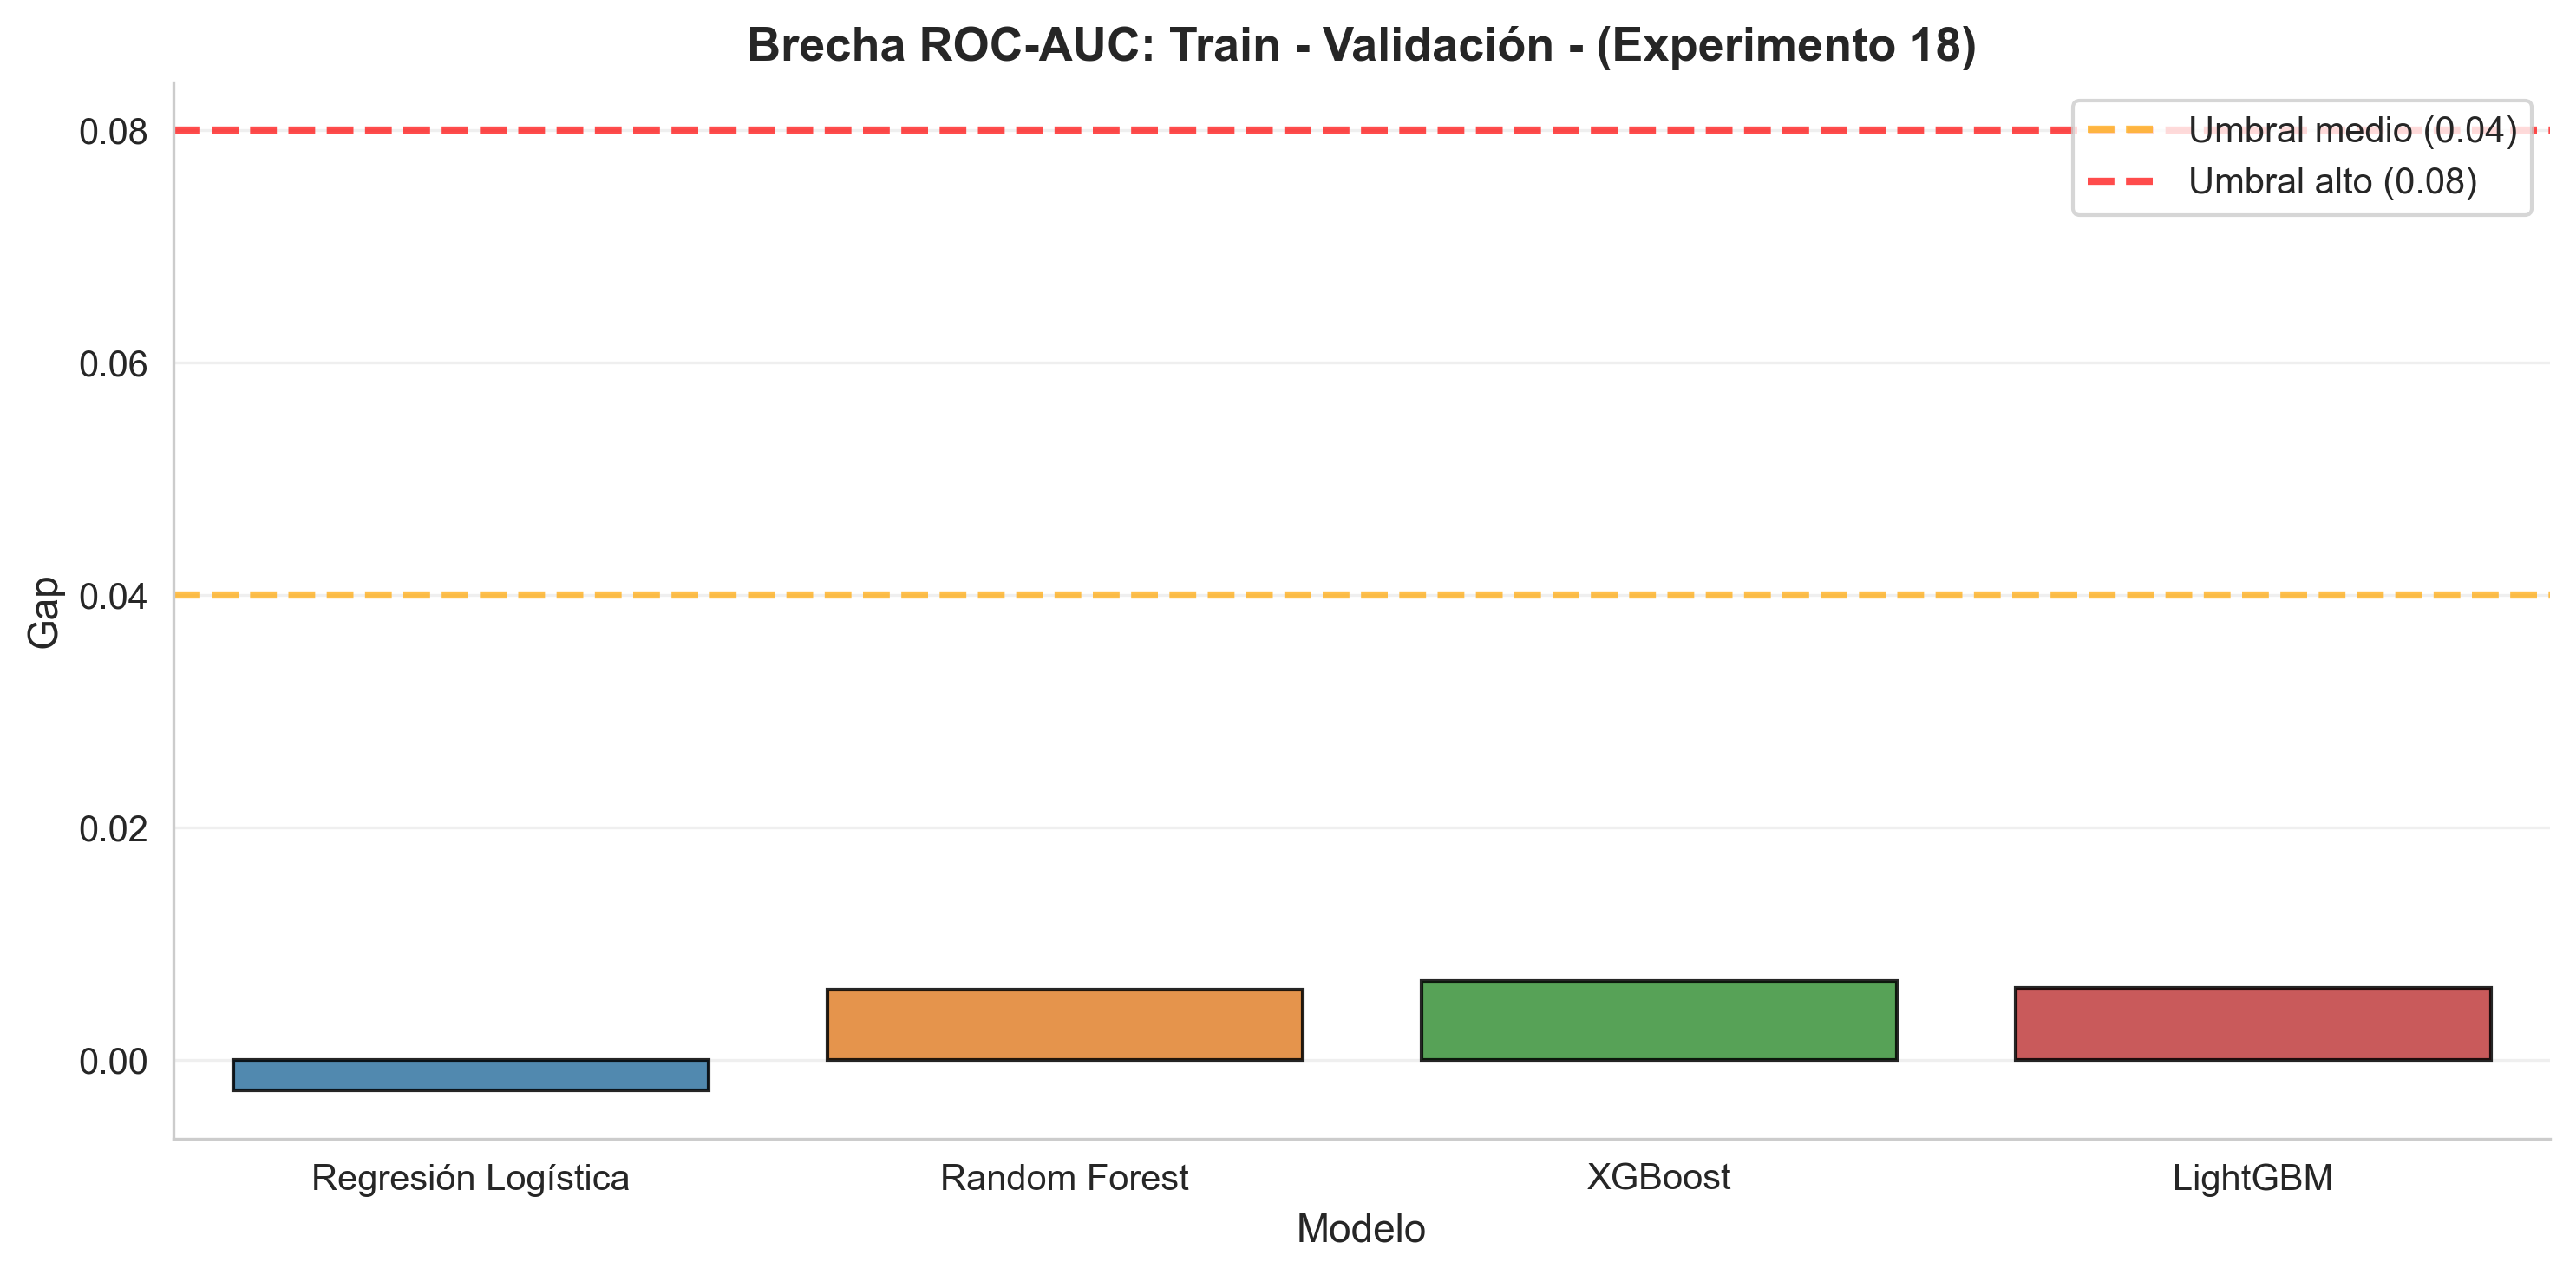

In [19]:
def plot_overfitting(overfit_data):
    """Visualiza diagnóstico de sobreajuste."""
    available_models = [m for m in MODELS if m in overfit_data]
    if not available_models:
        print('No hay diagnósticos de sobreajuste disponibles.')
        return

    rows = []
    for model in available_models:
        d = overfit_data[model]
        rows.append({
            'model': model,
            'model_name': MODEL_NAMES.get(model, model),
            'train_f1': d.get('train_f1_score'),
            'val_f1': d.get('val_f1_score'),
            'gap_f1': d.get('gap_f1_score'),
            'train_auc': d.get('train_roc_auc'),
            'val_auc': d.get('val_roc_auc'),
            'gap_auc': d.get('gap_roc_auc'),
            'risk': d.get('overfitting_risk', 'desconocido'),
        })

    overfit_df = pd.DataFrame(rows)
    display(
        overfit_df[['model_name', 'train_f1', 'val_f1', 'gap_f1', 'train_auc', 'val_auc', 'gap_auc', 'risk']]
        .rename(columns={
            'model_name': 'Modelo',
            'train_f1': 'F1 Train',
            'val_f1': 'F1 Val',
            'gap_f1': 'Gap F1',
            'train_auc': 'AUC Train',
            'val_auc': 'AUC Val',
            'gap_auc': 'Gap AUC',
            'risk': 'Riesgo',
        })
    )

    # Gráfico: Gap ROC-AUC
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(
        data=overfit_df,
        x='model_name',
        y='gap_auc',
        palette=COLORES,
        alpha=0.85,
        edgecolor='black',
    )
    # Colocar numero de experimento en el título
    experiment_id = globals().get('SELECTED_EXPERIMENT', 'N/A')
    ax.set_title(f'Brecha ROC-AUC: Train - Validación - (Experimento {experiment_id})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Modelo', fontsize=11)
    ax.set_ylabel('Gap', fontsize=11)
    ax.axhline(0.04, color='orange', linestyle='--', linewidth=2, label='Umbral medio (0.04)', alpha=0.7)
    ax.axhline(0.08, color='red', linestyle='--', linewidth=2, label='Umbral alto (0.08)', alpha=0.7)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)
    sns.despine()
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / f'report/figures/training/overfitting_gap_auc_{experiment_id}.png', dpi=300, bbox_inches='tight')
    plt.show()

if globals().get('EXPERIMENT_DIR') is not None and 'overfit_data' in globals():
    plot_overfitting(overfit_data)
else:
    print('No hay experimento seleccionado o datos de sobreajuste cargados.')

### 8.3 Mejores Hiperparámetros y Umbrales

In [18]:
def show_best_params_and_thresholds(best_params_data, threshold_data):
    """Muestra mejores hiperparámetros y umbrales."""
    rows = []

    for model in MODELS:
        params = best_params_data.get(model, {})
        threshold_info = threshold_data.get(model, {})

        row = {
            'model': model,
            'model_name': MODEL_NAMES.get(model, model),
            'best_threshold': threshold_info.get('best_threshold'),
            'tuned_on': threshold_info.get('tuned_on'),
        }

        if isinstance(params, dict):
            for key, value in params.items():
                row[f'param_{key}'] = value

        rows.append(row)

    if rows:
        params_df = pd.DataFrame(rows)
        display(params_df)
    else:
        print('No hay hiperparámetros disponibles.')

if EXPERIMENT_DIR is not None:
    show_best_params_and_thresholds(best_params_data, threshold_data)

,model,model_name,best_threshold,tuned_on,param_penalty,param_solver,param_C,param_class_weight,param_n_estimators,param_max_depth,...,param_bootstrap,param_learning_rate,param_subsample,param_colsample_bytree,param_min_child_weight,param_gamma,param_reg_alpha,param_reg_lambda,param_num_leaves,param_min_child_samples
0,LR,Regresión Logística,0.405,validation_set,l1,liblinear,1.916102,balanced,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RF,Random Forest,0.350,validation_set,NaN,NaN,NaN,balanced,495.0,6.0,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,XGB,XGBoost,0.380,validation_set,NaN,NaN,NaN,NaN,1338.0,4.0,...,NaN,0.005832,0.675693,0.682836,11.0,2.859972,2.057348,0.017436,NaN,NaN
3,LGBM,LightGBM,0.340,validation_set,NaN,NaN,NaN,NaN,1334.0,6.0,...,NaN,0.002770,0.868046,0.831051,NaN,NaN,2.004303,0.000358,20.0,69.0


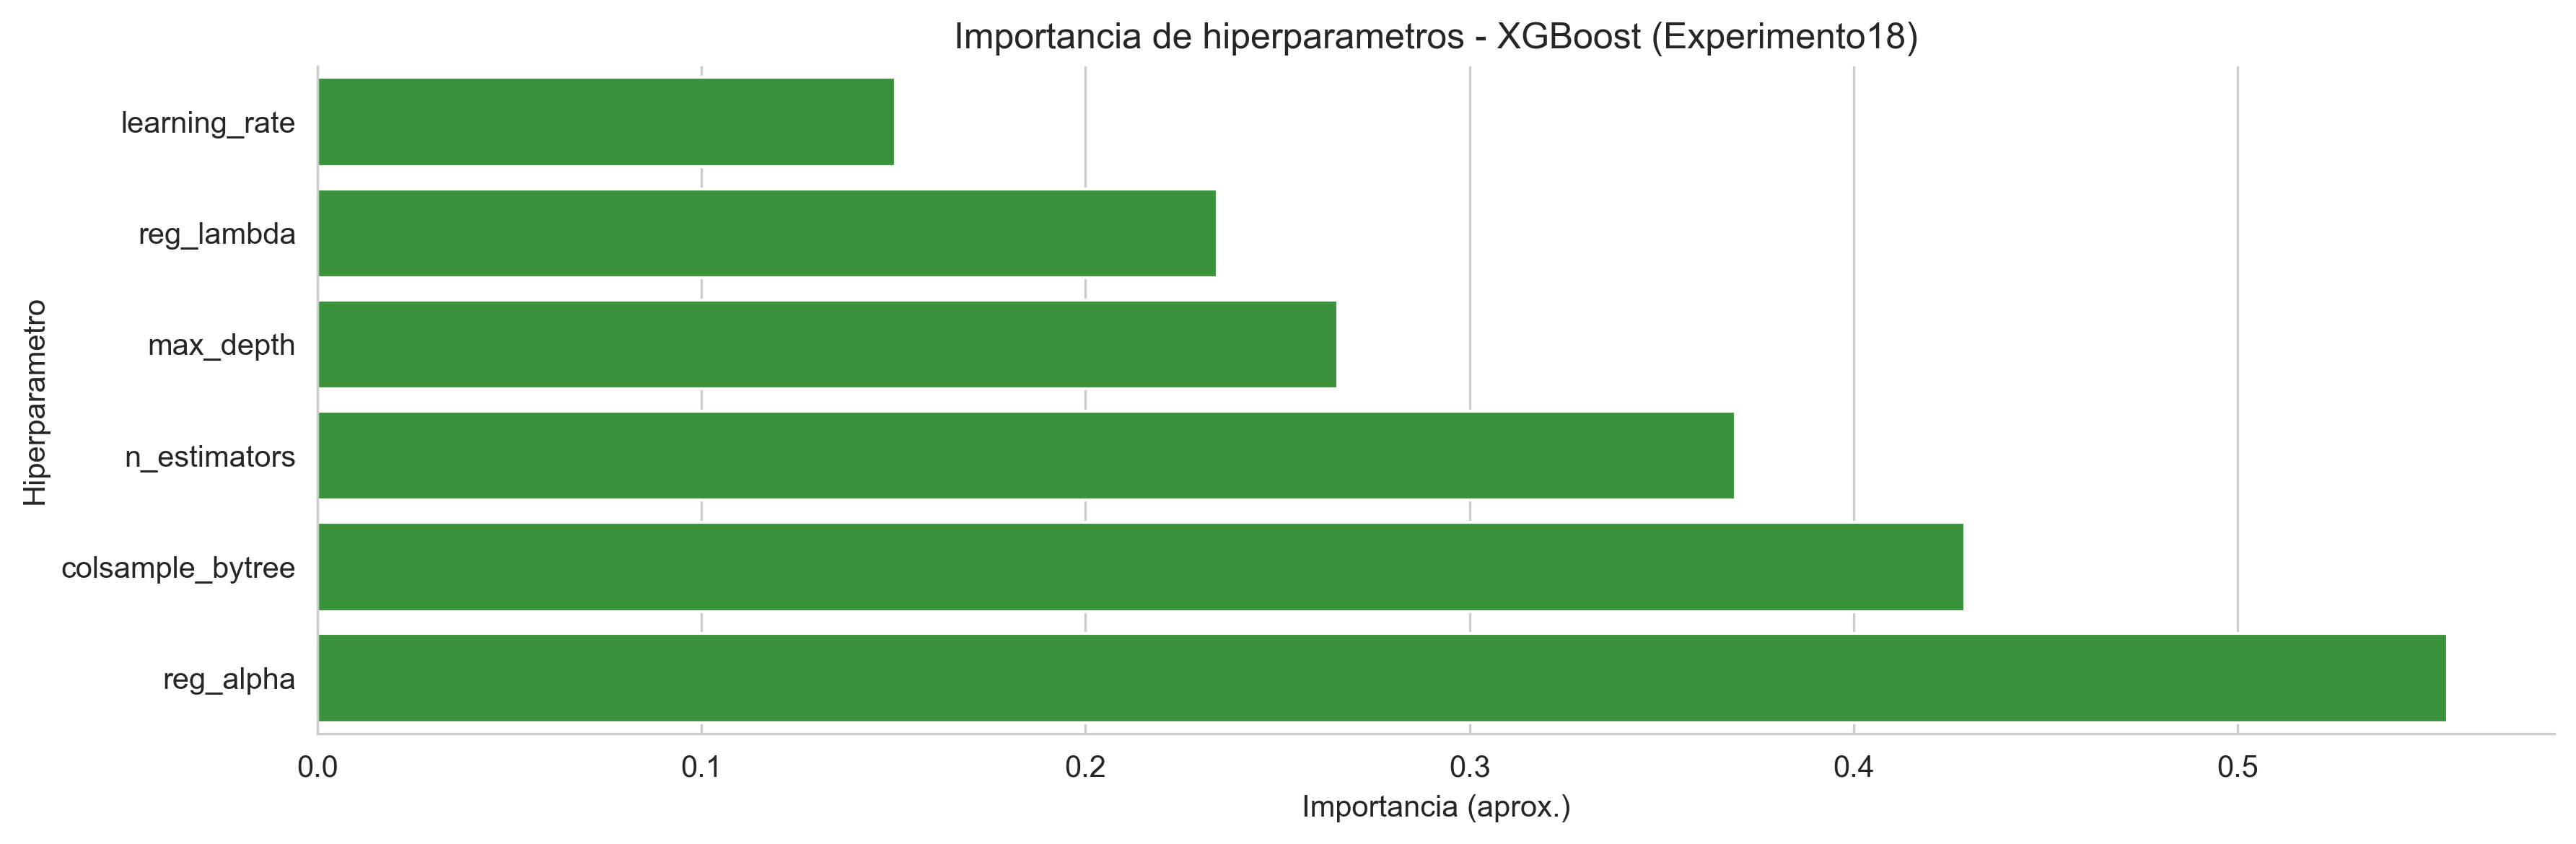

,param,importance
0,reg_alpha,0.554641
1,colsample_bytree,0.428855
2,n_estimators,0.369087
3,max_depth,0.265610
4,reg_lambda,0.234382
5,learning_rate,0.150524


In [20]:
SELECTED_OPTUNA_MODEL = "XGB"
TOP_K_PARAMS = 6
MAX_PARALLEL_ROWS = 250
experiment_id = globals().get('SELECTED_EXPERIMENT', 'N/A')

def build_trials_param_df(trials_data, model):
    if model not in trials_data:
        return pd.DataFrame()
    tdf = trials_data[model].copy()
    if "state" in tdf.columns:
        mask = tdf["state"].astype(str).str.upper().str.contains("COMPLETE")
        tdf = tdf[mask].copy()
    if tdf.empty or "value" not in tdf.columns:
        return pd.DataFrame()

    param_cols = [c for c in tdf.columns if c.startswith("params_") or c.startswith("param_")]
    if not param_cols:
        return pd.DataFrame()

    out = tdf[["value"] + param_cols].copy()
    rename_map = {c: re.sub(r"^params?_", "", c) for c in param_cols}
    out = out.rename(columns=rename_map)
    return out

def compute_param_importance(trials_df):
    if trials_df.empty or "value" not in trials_df.columns:
        return pd.DataFrame()

    df = trials_df.copy()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["value"])
    if df.empty:
        return pd.DataFrame()

    total_var = df["value"].var()
    if pd.isna(total_var) or total_var == 0:
        return pd.DataFrame()

    importance_rows = []
    param_cols = [c for c in df.columns if c != "value"]
    for col in param_cols:
        series = df[col]
        if pd.api.types.is_numeric_dtype(series):
            numeric = pd.to_numeric(series, errors="coerce")
            corr = numeric.corr(df["value"], method="spearman")
            importance = abs(corr) if pd.notna(corr) else 0.0
        else:
            group_df = pd.DataFrame({"param": series.astype(str), "value": df["value"]})
            overall_mean = group_df["value"].mean()
            ss_total = ((group_df["value"] - overall_mean) ** 2).sum()
            group_stats = group_df.groupby("param")["value"].agg(["mean", "count"])
            ss_between = (group_stats["count"] * (group_stats["mean"] - overall_mean) ** 2).sum()
            importance = ss_between / ss_total if ss_total > 0 else 0.0
        importance_rows.append({"param": col, "importance": float(importance)})

    return (
        pd.DataFrame(importance_rows)
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

def plot_param_importance(importance_df, model_label, top_k=6, title_suffix=""):
    if importance_df.empty:
        print("No hay parametros para calcular importancia.")
        return

    plot_df = importance_df.head(top_k).iloc[::-1]
    model_color = COLORES.get(model_label, "#1f77b4")
    plt.figure(figsize=(12, 4))
    ax = sns.barplot(data=plot_df, x="importance", y="param", color=model_color)
    ax.set_title(f"Importancia de hiperparametros - {model_label}{title_suffix}")
    ax.set_xlabel("Importancia (aprox.)")
    ax.set_ylabel("Hiperparametro")
    ax.grid(axis="x", alpha=0.99)
    sns.despine()
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / f'report/figures/training/param_importance_{model_label}_{experiment_id}.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_parallel_coordinates(
    trials_df,
    model_label,
    param_cols,
    title_suffix="",
    max_rows=250,
    random_state=42,
 ):
    if trials_df.empty or not param_cols:
        print("No hay parametros suficientes para coordenadas paralelas.")
        return

    plot_df = trials_df[["value"] + param_cols].copy()
    plot_df = plot_df.dropna(subset=["value"])
    if plot_df.empty:
        print("No hay datos suficientes para coordenadas paralelas.")
        return

    if len(plot_df) > max_rows:
        plot_df = plot_df.sample(n=max_rows, random_state=random_state)

    plot_df["tier"] = pd.qcut(
        plot_df["value"],
        q=3,
        labels=["bajo", "medio", "alto"],
        duplicates="drop",
    )

    for col in param_cols:
        series = plot_df[col]
        if pd.api.types.is_numeric_dtype(series):
            numeric = pd.to_numeric(series, errors="coerce")
            min_val = numeric.min()
            max_val = numeric.max()
            if pd.isna(min_val) or pd.isna(max_val) or min_val == max_val:
                plot_df[col] = 0.5
            else:
                plot_df[col] = (numeric - min_val) / (max_val - min_val)
        else:
            codes = series.astype(str).astype("category").cat.codes
            plot_df[col] = codes / codes.max() if codes.max() > 0 else 0.5

    plt.figure(figsize=(12, 6))
    parallel_coordinates(
        plot_df[["tier"] + param_cols],
        "tier",
        color=["#f28e2b", "#4e79a7", "#59a14f"],
        alpha=0.65,
        linewidth=1.8,
    )
    plt.title(f"Coordenadas paralelas (normalizado) - {model_label}{title_suffix}")
    plt.ylabel("Valor normalizado")
    plt.xticks(rotation=20)
    plt.grid(axis="y", alpha=0.2)
    sns.despine()
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / f'report/figures/training/parallel_coordinates_{experiment_id}.png', dpi=300, bbox_inches='tight')
    plt.show()

def build_hyperparam_threshold_summary(best_params_data, threshold_data, models):
    rows = []
    param_keys = set()

    for model in models:
        params = best_params_data.get(model, {})
        threshold_payload = threshold_data.get(model, {})

        row = {
            "model": model,
            "model_name": MODEL_NAMES.get(model, model),
            "best_threshold": threshold_payload.get("best_threshold"),
            "tuned_on": threshold_payload.get("tuned_on"),
        }

        if isinstance(params, dict):
            for key, value in params.items():
                row[key] = value
                param_keys.add(key)

        rows.append(row)

    if not rows:
        return pd.DataFrame()

    base_cols = ["model_name", "model", "best_threshold", "tuned_on"]
    param_cols = sorted(param_keys)
    df = pd.DataFrame(rows)
    order_map = {name: idx for idx, name in enumerate(MODEL_ORDER)}
    df["_order"] = df["model_name"].map(order_map)
    df = df.sort_values("_order").drop(columns=["_order"])
    return df[base_cols + param_cols]

optuna_params_df = pd.DataFrame()
optuna_importance_df = pd.DataFrame()

if EXPERIMENT_DIR is None:
    print("Selecciona un experimento valido para analizar hiperparametros.")
elif SELECTED_OPTUNA_MODEL not in trials_data:
    print("No hay optuna_trials para el modelo seleccionado.")
else:
    optuna_params_df = build_trials_param_df(trials_data, SELECTED_OPTUNA_MODEL)
    optuna_importance_df = compute_param_importance(optuna_params_df)
    model_label = MODEL_NAMES.get(SELECTED_OPTUNA_MODEL, SELECTED_OPTUNA_MODEL)
    plot_param_importance(
        optuna_importance_df,
        model_label,
        top_k=TOP_K_PARAMS,
        title_suffix=f" ({EXPERIMENT_DIR.name})",
    )
    if not optuna_importance_df.empty:
        display(optuna_importance_df.head(TOP_K_PARAMS))

### 8.4 Coordenadas Paralelas

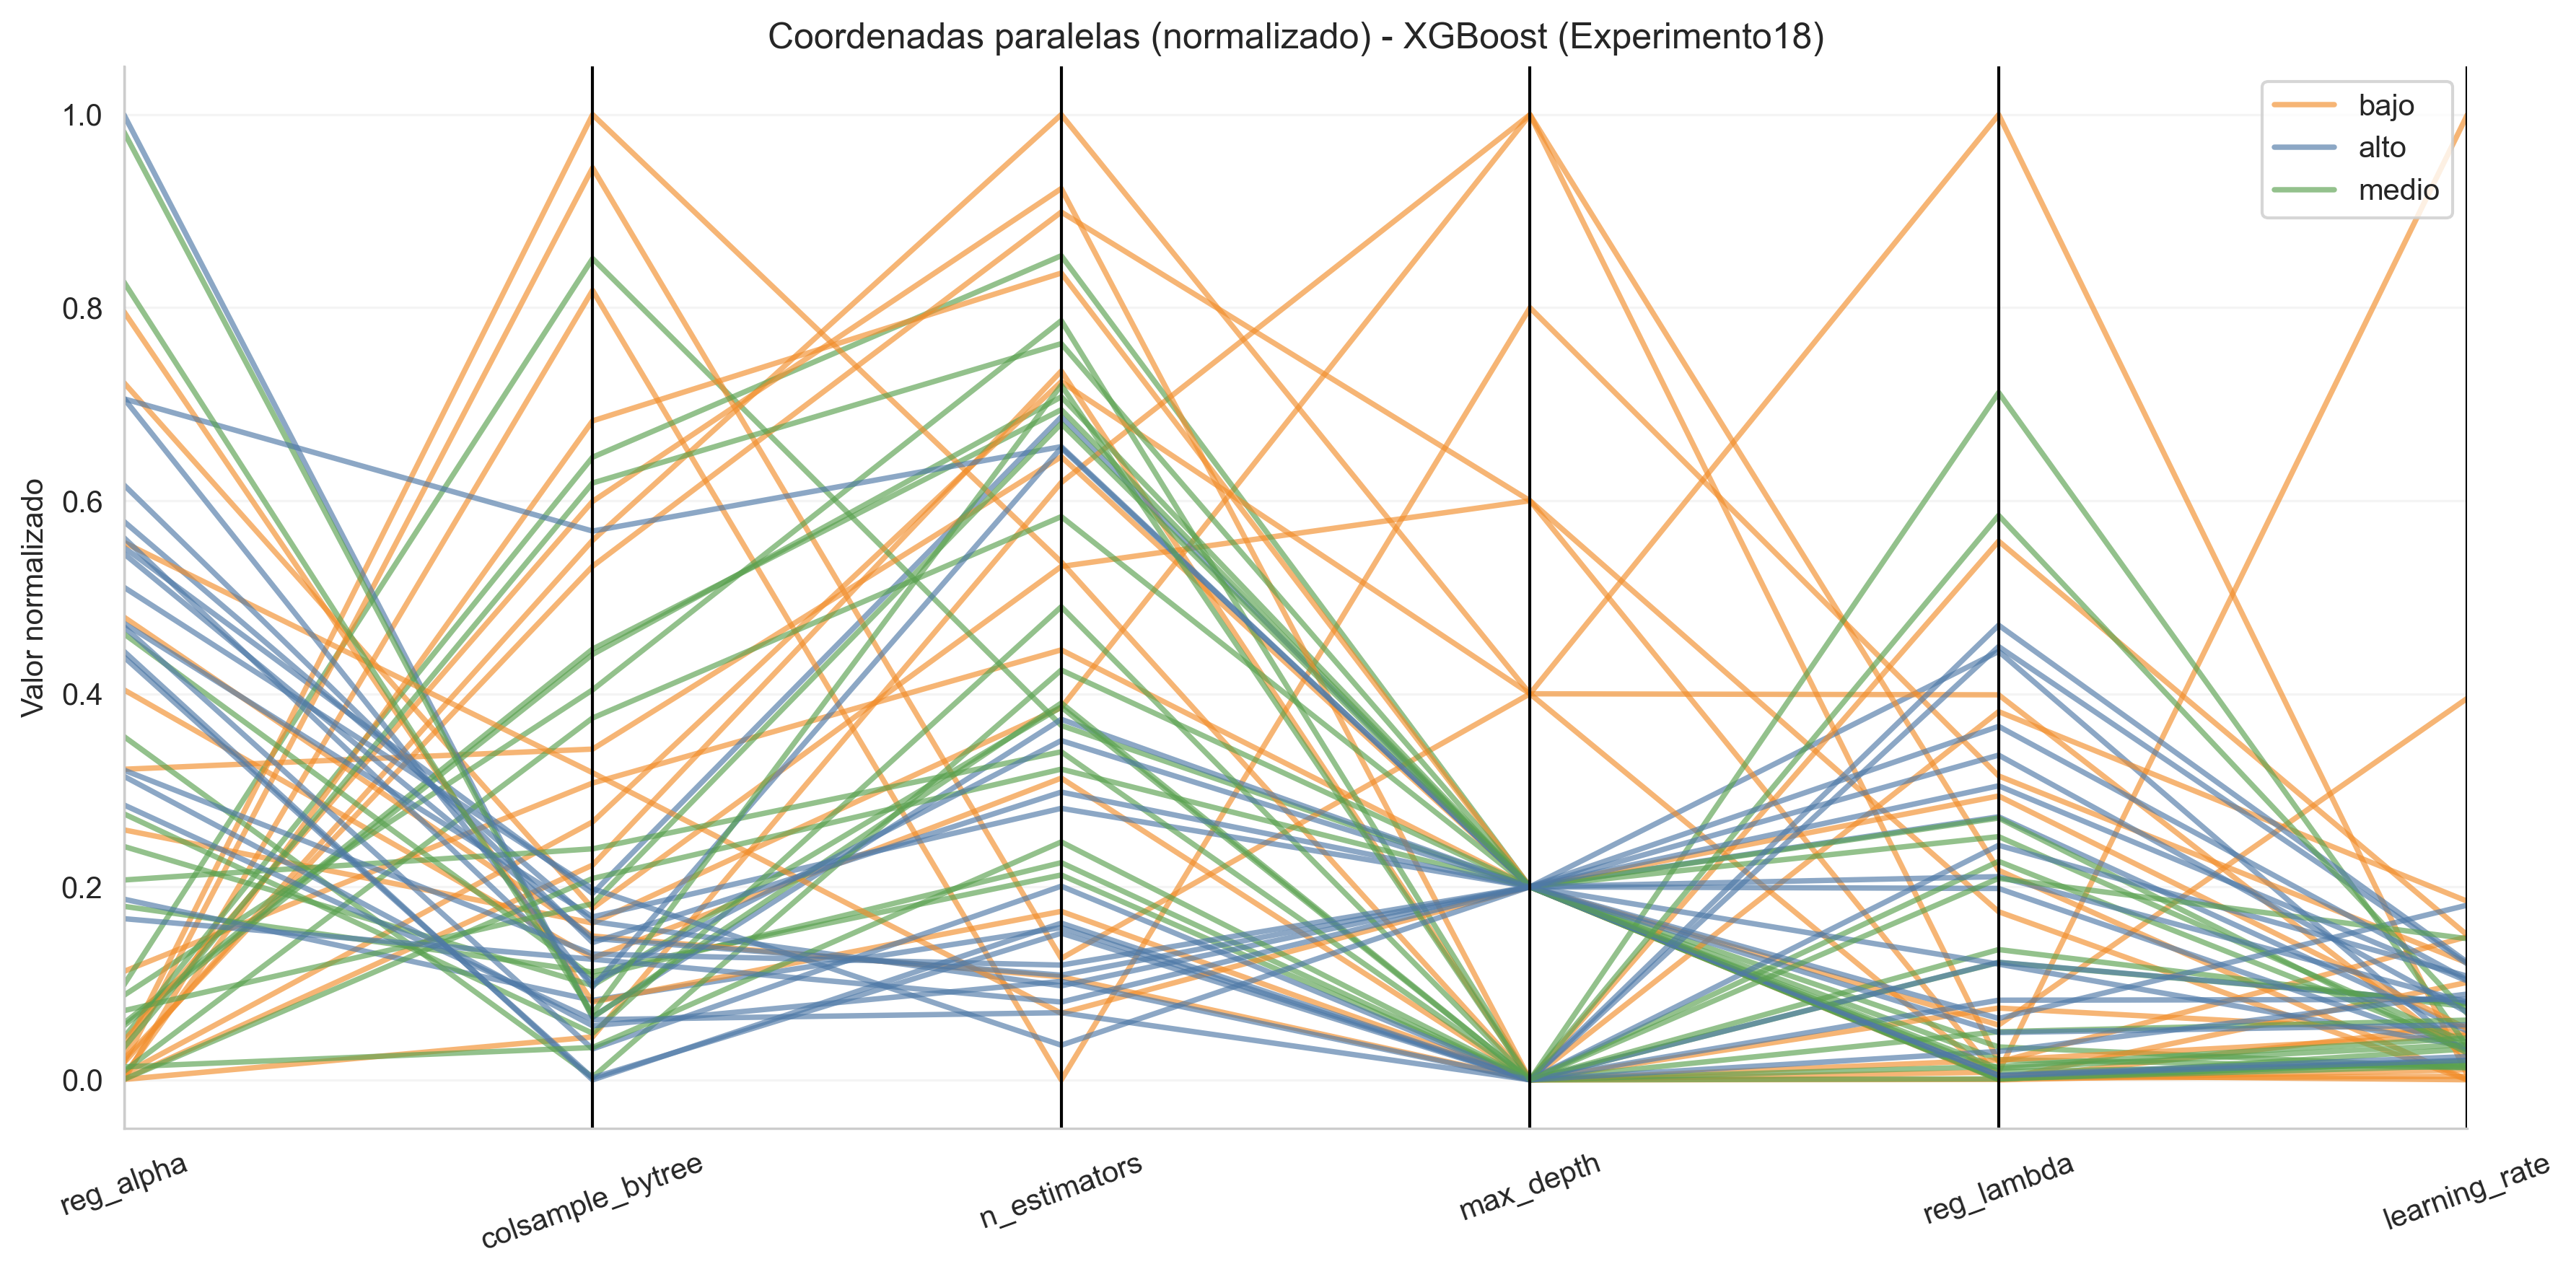

In [21]:
# Graficar Coordenadas Paralealas 
if "SELECTED_OPTUNA_MODEL" not in globals():
    SELECTED_OPTUNA_MODEL = "XGB"
if "TOP_K_PARAMS" not in globals():
    TOP_K_PARAMS = 6
if "MAX_PARALLEL_ROWS" not in globals():
    MAX_PARALLEL_ROWS = 250

if EXPERIMENT_DIR is None:
    print("Selecciona un experimento valido para coordenadas paralelas.")
elif SELECTED_OPTUNA_MODEL not in trials_data:
    print("No hay optuna_trials para el modelo seleccionado.")
else:
    if "optuna_params_df" not in globals() or optuna_params_df.empty:
        optuna_params_df = build_trials_param_df(trials_data, SELECTED_OPTUNA_MODEL)
    if "optuna_importance_df" not in globals() or optuna_importance_df.empty:
        optuna_importance_df = compute_param_importance(optuna_params_df)

    model_label = MODEL_NAMES.get(SELECTED_OPTUNA_MODEL, SELECTED_OPTUNA_MODEL)
    if optuna_importance_df.empty:
        print("No hay parametros para coordenadas paralelas.")
    else:
        top_params = optuna_importance_df["param"].head(TOP_K_PARAMS).tolist()
        plot_parallel_coordinates(
            optuna_params_df,
            model_label,
            top_params,
            title_suffix=f" ({EXPERIMENT_DIR.name})",
            max_rows=MAX_PARALLEL_ROWS,
        )

## 6.8 Tabla Consolidada de Experimentos

In [22]:
# Compilar y mostrar solo la tabla coloreada consolidada
consolidated_metrics = []
for exp_num, exp_path in EXPERIMENT_DIRS:
    ta = exp_path / 'training_artifacts'
    if not ta.exists():
        continue
    for model in MODELS:
        mf = ta / f'val_metrics_{model}.csv'
        if not mf.exists():
            continue
        try:
            r = pd.read_csv(mf).iloc[0]
            consolidated_metrics.append({
                'Experimento': int(exp_num),
                'Modelo': MODEL_NAMES.get(model, model),
                'Código': model,
                'FOC': float(r.get('best_cv_composite_score', 0)),
                'ROC-AUC': float(r.get('val_roc_auc', 0)),
                'F1-Score': float(r.get('val_f1_score', 0)),
                'Accuracy': float(r.get('val_accuracy', 0)),
                'Precision': float(r.get('val_precision', 0)),
                'Recall': float(r.get('val_recall', 0)),
                'MCC': float(r.get('val_mcc', 0)),
                'Threshold': float(r.get('best_threshold', 0)),
            })
        except Exception:
            pass

df_consolidated = pd.DataFrame(consolidated_metrics)
if df_consolidated.empty:
    print("No hay métricas disponibles para mostrar.")
else:
    df_consolidated = df_consolidated.sort_values(['Experimento', 'Modelo']).reset_index(drop=True)
    styled_table = df_consolidated.style.format({
        'FOC': '{:.4f}',
        'ROC-AUC': '{:.4f}',
        'F1-Score': '{:.4f}',
        'Accuracy': '{:.4f}',
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
        'MCC': '{:.4f}',
        'Threshold': '{:.4f}',
    }).background_gradient(
        subset=['ROC-AUC', 'F1-Score', 'Accuracy', 'MCC'],
        cmap='RdYlGn',
        vmin=0, vmax=1
    ).set_properties(**{'font-size': '9pt', 'border': '1px solid grey'})

    try:
        display(styled_table)
    except Exception:
        display.display(styled_table)


,Experimento,Modelo,Código,FOC,ROC-AUC,F1-Score,Accuracy,Precision,Recall,MCC,Threshold
0,1,LightGBM,LGBM,0.7728,0.7987,0.7378,0.7100,0.6675,0.8247,0.4331,0.4050
1,1,Random Forest,RF,0.7718,0.7975,0.7369,0.7083,0.6654,0.8257,0.4304,0.3650
2,1,Regresión Logística,LR,0.7673,0.7928,0.7338,0.7096,0.6715,0.8090,0.4293,0.4000
3,1,XGBoost,XGB,0.7750,0.8009,0.7367,0.7018,0.6542,0.8431,0.4229,0.3350
4,2,LightGBM,LGBM,0.7734,0.8000,0.7355,0.7044,0.6601,0.8303,0.4244,0.3450
5,2,Random Forest,RF,0.7721,0.7975,0.7369,0.7083,0.6654,0.8257,0.4304,0.3650
6,2,Regresión Logística,LR,0.7674,0.7928,0.7338,0.7096,0.6715,0.8090,0.4293,0.4000
7,2,XGBoost,XGB,0.7753,0.8009,0.7367,0.7018,0.6542,0.8431,0.4229,0.3350
8,3,LightGBM,LGBM,0.7752,0.7993,0.7354,0.7065,0.6639,0.8240,0.4268,0.3700
9,3,Random Forest,RF,0.7742,0.7990,0.7362,0.7036,0.6578,0.8358,0.4243,0.3400


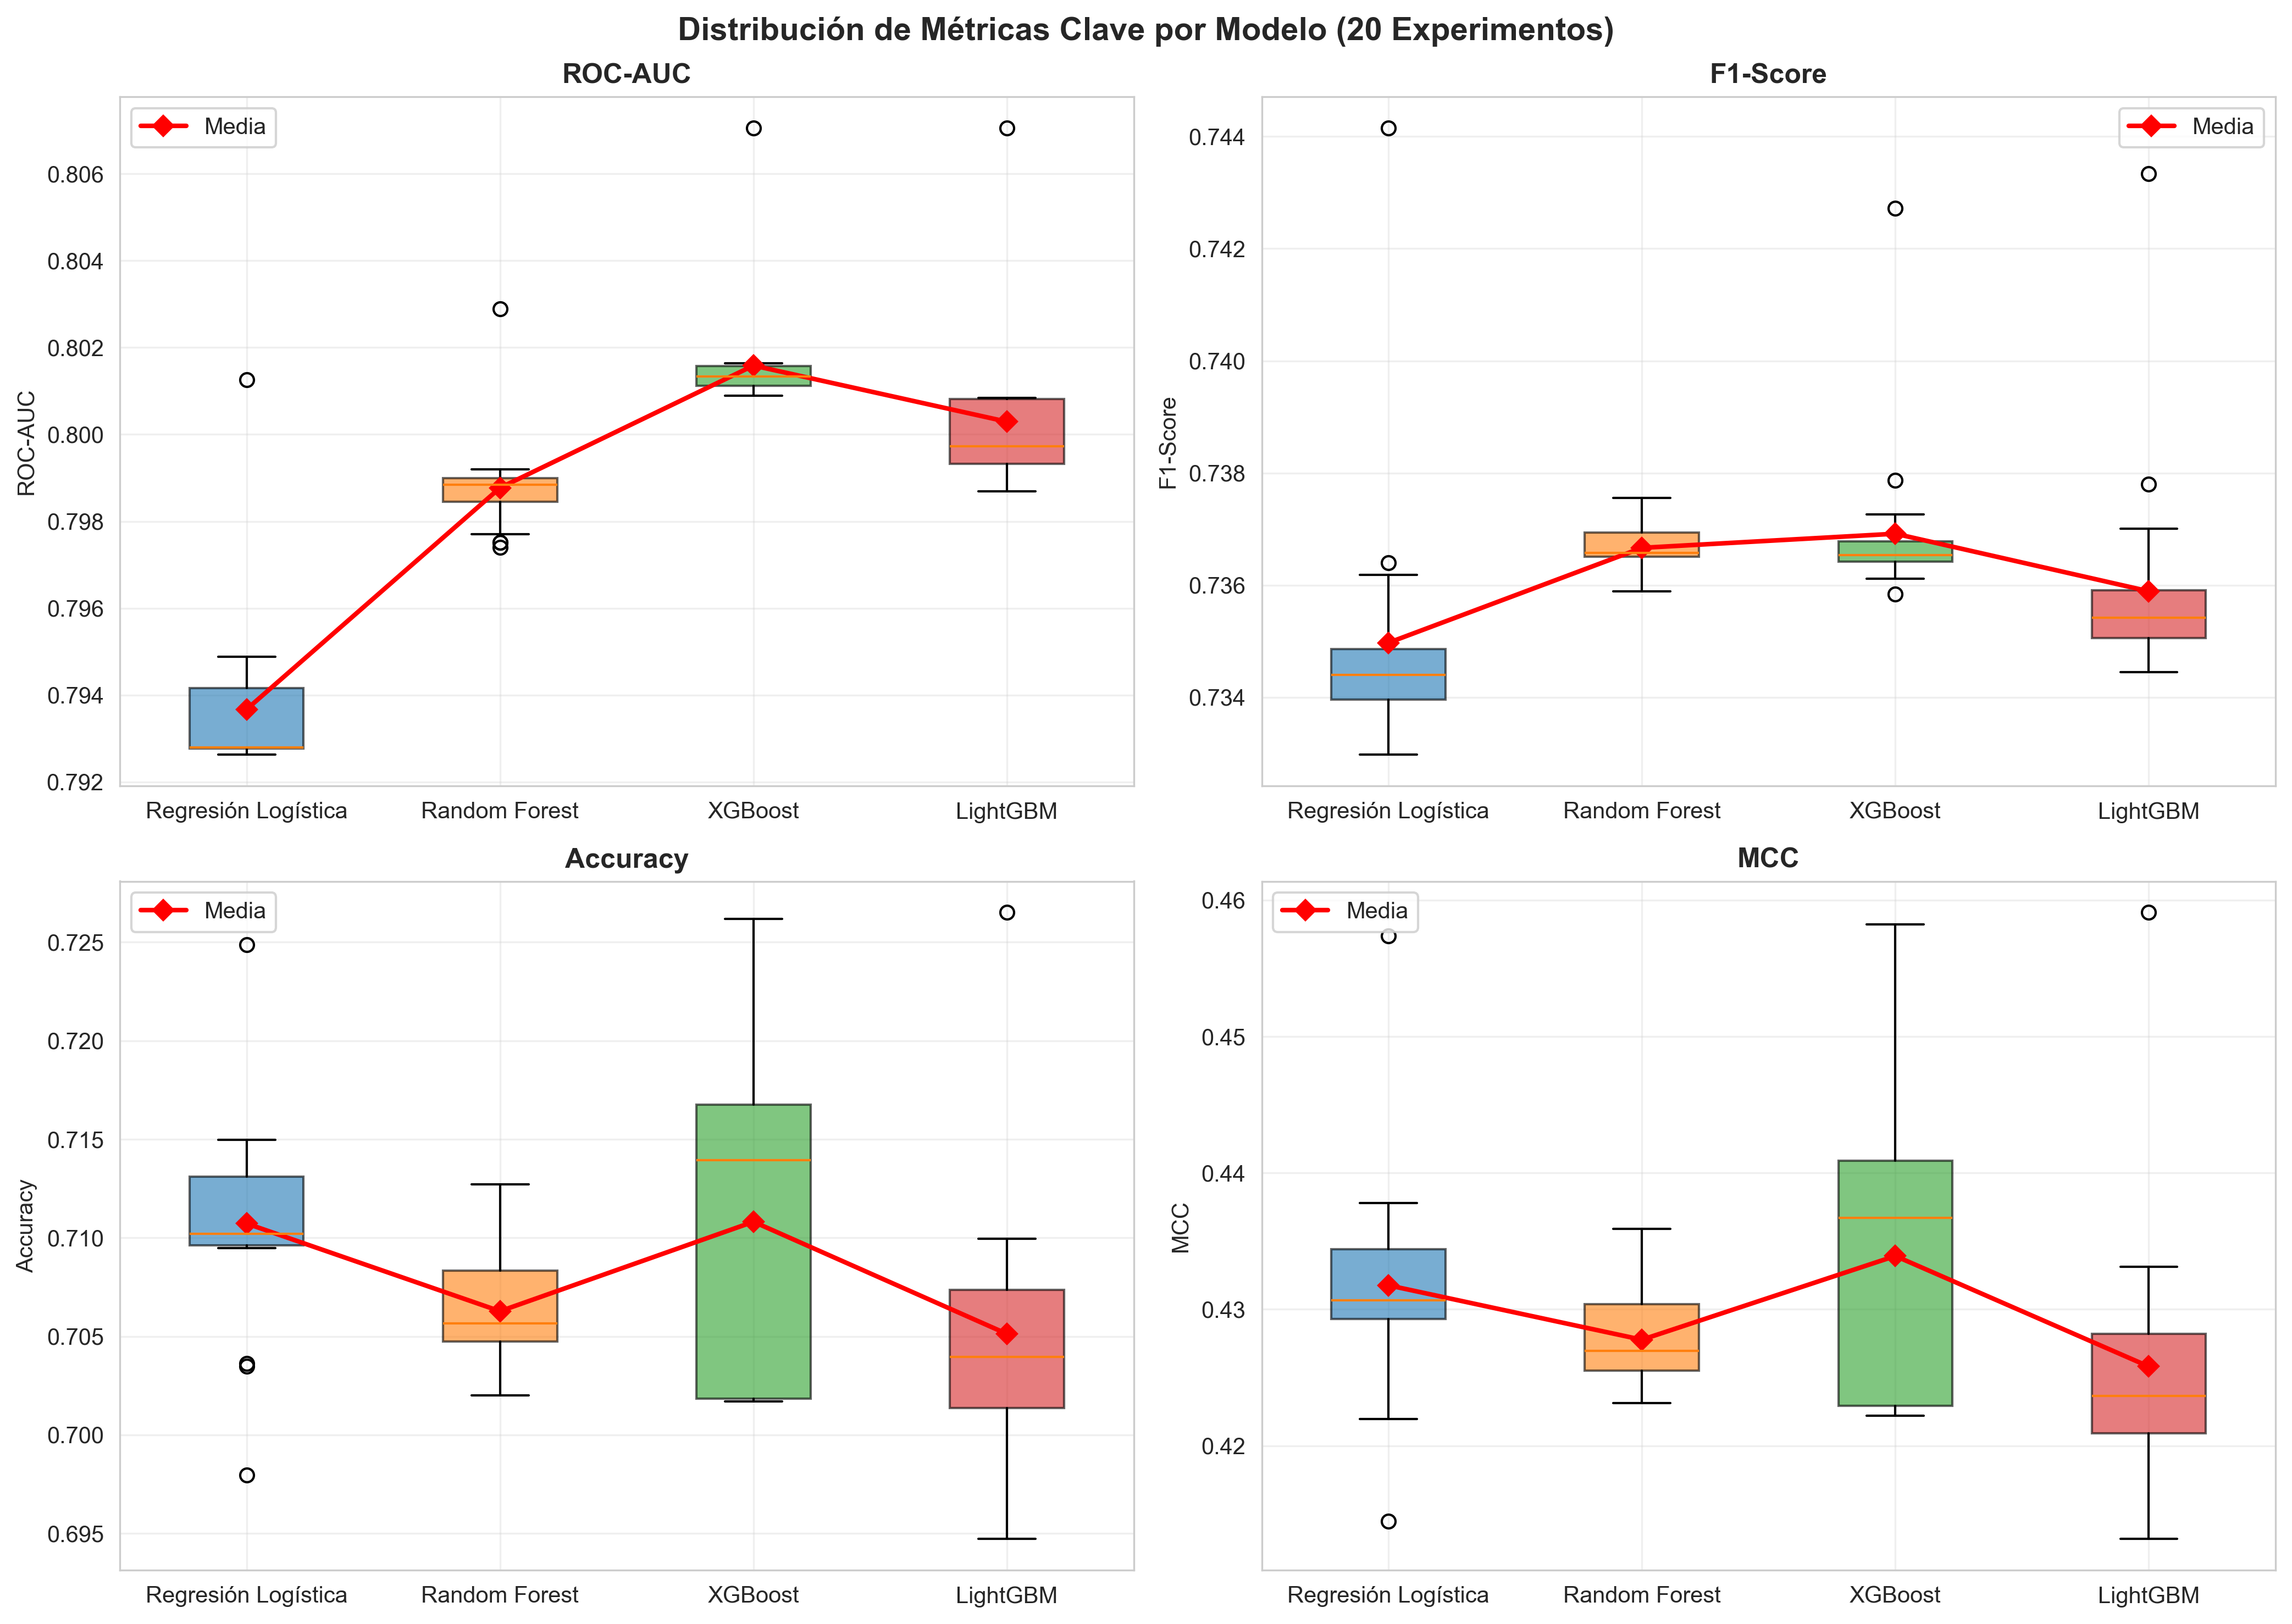



ESTADÍSTICAS DETALLADAS POR MODELO:

Regresión Logística:
  ROC-AUC   → Media: 0.7937 ± 0.0020 (Min: 0.7926, Max: 0.8013)
  F1-Score  → Media: 0.7350 ± 0.0023 (Min: 0.7330, Max: 0.7442)
  Accuracy  → Media: 0.7107 ± 0.0053 (Min: 0.6980, Max: 0.7249)
  MCC       → Media: 0.4318 ± 0.0082 (Min: 0.4145, Max: 0.4574)

Random Forest:
  ROC-AUC   → Media: 0.7988 ± 0.0011 (Min: 0.7974, Max: 0.8029)
  F1-Score  → Media: 0.7367 ± 0.0004 (Min: 0.7359, Max: 0.7376)
  Accuracy  → Media: 0.7063 ± 0.0029 (Min: 0.7020, Max: 0.7127)
  MCC       → Media: 0.4278 ± 0.0036 (Min: 0.4231, Max: 0.4359)

XGBoost:
  ROC-AUC   → Media: 0.8016 ± 0.0013 (Min: 0.8009, Max: 0.8070)
  F1-Score  → Media: 0.7369 ± 0.0014 (Min: 0.7358, Max: 0.7427)
  Accuracy  → Media: 0.7108 ± 0.0078 (Min: 0.7017, Max: 0.7262)
  MCC       → Media: 0.4339 ± 0.0103 (Min: 0.4222, Max: 0.4582)

LightGBM:
  ROC-AUC   → Media: 0.8003 ± 0.0018 (Min: 0.7987, Max: 0.8070)
  F1-Score  → Media: 0.7359 ± 0.0019 (Min: 0.7345, Max: 0.7433)
  Accur

In [23]:
# Visualización comparativa de métricas por modelo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Métricas Clave por Modelo (20 Experimentos)', fontsize=14, fontweight='bold')

metrics_to_plot = ['ROC-AUC', 'F1-Score', 'Accuracy', 'MCC']
positions_per_ax = [(0, 0), (0, 1), (1, 0), (1, 1)]

for metric, (row, col) in zip(metrics_to_plot, positions_per_ax):
    ax = axes[row, col]
    data_by_model = [df_consolidated[df_consolidated['Modelo'] == m][metric].values for m in MODEL_ORDER]
    bp = ax.boxplot(data_by_model, labels=MODEL_ORDER, patch_artist=True)
    
    # Colorear boxplots
    for patch, model_name in zip(bp['boxes'], MODEL_ORDER):
        patch.set_facecolor(COLORES[model_name])
        patch.set_alpha(0.6)
    
    ax.set_title(f'{metric}', fontweight='bold')
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
    
    # Añadir valores medios
    means = [df_consolidated[df_consolidated['Modelo'] == m][metric].mean() for m in MODEL_ORDER]
    ax.plot(range(1, len(MODEL_ORDER)+1), means, 'D-', color='red', markersize=6, label='Media', linewidth=2)
    ax.legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / f'report/figures/training/validation_metrics_box_{experiment_id}.png', dpi=300, bbox_inches='tight')
plt.show()

# Tabla de estadísticas detalladas por modelo
print("\n\nESTADÍSTICAS DETALLADAS POR MODELO:")
print("=" * 140)
for model_name in MODEL_ORDER:
    model_data = df_consolidated[df_consolidated['Modelo'] == model_name]
    print(f"\n{model_name}:")
    print(f"  ROC-AUC   → Media: {model_data['ROC-AUC'].mean():.4f} ± {model_data['ROC-AUC'].std():.4f} (Min: {model_data['ROC-AUC'].min():.4f}, Max: {model_data['ROC-AUC'].max():.4f})")
    print(f"  F1-Score  → Media: {model_data['F1-Score'].mean():.4f} ± {model_data['F1-Score'].std():.4f} (Min: {model_data['F1-Score'].min():.4f}, Max: {model_data['F1-Score'].max():.4f})")
    print(f"  Accuracy  → Media: {model_data['Accuracy'].mean():.4f} ± {model_data['Accuracy'].std():.4f} (Min: {model_data['Accuracy'].min():.4f}, Max: {model_data['Accuracy'].max():.4f})")
    print(f"  MCC       → Media: {model_data['MCC'].mean():.4f} ± {model_data['MCC'].std():.4f} (Min: {model_data['MCC'].min():.4f}, Max: {model_data['MCC'].max():.4f})")


## 7. Conclusiones

Este notebook proporciona un análisis integral de:

1. **Evolución de modelos**: Seguimiento de ROC-AUC y F1-Score a lo largo de 20 experimentos.
2. **Validación de calidad**: Cobertura de artefactos y completitud de datos.
3. **Diagnósticos de sobreajuste**: Identificación de modelos con riesgo de sobreajuste.
4. **Rendimiento comparativo**: Comparación de métricas entre diferentes modelos.
5. **Configuración final**: Hiperparámetros y umbrales seleccionados para cada modelo.

La selección final de modelos se realiza basándose en el equilibrio entre ROC-AUC, F1-Score y riesgo de sobreajuste en la validación.